# Bias Classification using Internal Attention Representations

## Abstract
This notebook explores the capability of GPT-2's internal attention mechanisms to detect biased statements *without* fine-tuning the model weights. We extract granular attention features from a pre-trained `gpt2` model and use them to train classifiers. The workflow includes rigorous validation, hyperparameter tuning, and advanced interpretability techniques.

## Methodology
1. **Setup and Imports**: Load required libraries and configure environment.
2. **Data Loading**: Load the bias classification dataset.
3. **Feature Extraction**: Extract ~2,000 attention features (GAM, Head Spec, ISA, Tree) per sentence.
4. **Preprocessing and EDA**: Remove constant features and visualize using PCA and t-SNE.
5. **Model Selection and Optimization**:
    - 5.1 Train/Test Split (80/20)
    - 5.2 Model Comparison via Cross-Validation
    - 5.3 Hyperparameter Tuning with HalvingRandomSearchCV
    - 5.4 Learning Curves for overfitting detection
6. **Final Model Evaluation**: Performance on held-out test set.
7. **Counterfactual Analysis**: Interpret decisions via nearest counterfactuals.
8. **Feature Importance Analysis**:
    - 8.1 SHAP Values
    - 8.2 Permutation Feature Importance
    - 8.3 Feature Stability Analysis
    - 8.4 Consensus Feature Ranking
9. **TF-IDF Baseline Comparison**: Compare against text-based baseline.
10. **Scientific Validation**: Bootstrap CIs, calibration, threshold analysis, error analysis.
11. **Live Prediction**: Test on new sentences.

In [1]:
import subprocess
import sys
import os

try:
    import spacy
    if not spacy.util.is_package("en_core_web_sm"):
        subprocess.check_call([sys.executable, "-m", "spacy", "download", "en_core_web_sm"])
except Exception as e:
    print(f"Spacy setup warning: {e}")

# 1. Setup and Imports

In [2]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import re

# ML Imports
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import (
    StratifiedKFold, StratifiedGroupKFold, GroupShuffleSplit,
    cross_val_predict, train_test_split, HalvingRandomSearchCV, cross_validate
)
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve, confusion_matrix,
    classification_report, f1_score, precision_score, recall_score,
)
from xgboost import XGBClassifier

# Project Imports
current_dir = os.getcwd()
if 'attention_app' in current_dir:
    while 'attention_app' in current_dir and os.path.basename(current_dir) != 'project':
        current_dir = os.path.dirname(current_dir)
    root_dir = current_dir
else:
    root_dir = current_dir

if root_dir not in sys.path: sys.path.append(root_dir)

from attention.models import ModelManager
from attention.bias.feature_extraction_notebooks import extract_features_for_sentence
sns.set_theme(style="whitegrid", context="notebook")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# 2. Data Loading

Load the bias classification dataset.

In [3]:
# Load Data
dataset_path = os.path.join(root_dir, 'dataset/v2', 'bias_sentences_v9.json')
with open(dataset_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

df_sentences = pd.DataFrame(data['entries'])
df_sentences['label'] = df_sentences['has_bias'].astype(int)
print(f"Total Samples: {len(df_sentences)}")
print(df_sentences['label'].value_counts())

# Diagnostic: text duplication analysis
n_unique_texts = df_sentences['text'].nunique()
n_total = len(df_sentences)
print(f"\nDuplicate Analysis:")
print(f"  Total rows: {n_total}")
print(f"  Unique texts: {n_unique_texts} ({n_total - n_unique_texts} duplicates)")

# Drop duplicate texts (keep first occurrence)
df_sentences = df_sentences.drop_duplicates(subset='text', keep='first').reset_index(drop=True)
print(f"  After drop_duplicates(subset='text'): {len(df_sentences)} rows")
print(f"  All texts now unique: {len(df_sentences) == df_sentences['text'].nunique()}")

Total Samples: 10304
label
1    5497
0    4807
Name: count, dtype: int64

Duplicate Analysis:
  Total rows: 10304
  Unique texts: 10304 (0 duplicates)
  After drop_duplicates(subset='text'): 10304 rows
  All texts now unique: True


# 3. Feature Extraction

Extract attention-based features from GPT-2 in batches to manage memory usage.

In [4]:
# Feature Extraction (Batched Processing)
# Process data in batches of 500 to prevent memory issues

BATCH_SIZE = 500
model_name = "gpt2"
manager = ModelManager()

# Calculate number of batches
total_samples = len(df_sentences)
num_batches = (total_samples + BATCH_SIZE - 1) // BATCH_SIZE

print(f"Processing {total_samples} samples in {num_batches} batches of up to {BATCH_SIZE} samples each...")

# Store batch results
batch_dfs = []

# Process each batch
for batch_idx in range(num_batches):
    start_idx = batch_idx * BATCH_SIZE
    end_idx = min(start_idx + BATCH_SIZE, total_samples)
    
    print(f"\nBatch {batch_idx + 1}/{num_batches}: Processing samples {start_idx} to {end_idx-1}...")
    
    # Extract features for current batch
    feature_rows = []
    batch_df = df_sentences.iloc[start_idx:end_idx]
    
    for index, row in tqdm(batch_df.iterrows(), total=len(batch_df), desc=f"Batch {batch_idx + 1}"):
        try:
            feats = extract_features_for_sentence(row['text'], model_name, manager)
            feats['label'] = row['label']
            feature_rows.append(feats)
        except Exception as e:
            print(f"  Skipping sample {index}: {e}")
    
    # Create DataFrame for this batch
    batch_df_features = pd.DataFrame(feature_rows).fillna(0)
    batch_dfs.append(batch_df_features)
    
    print(f"  Batch {batch_idx + 1} completed: {batch_df_features.shape[0]} samples, {batch_df_features.shape[1]} features")
    
    # Clear variables to free memory
    del feature_rows, batch_df_features

# Concatenate all batches
print("\n Combining all batches...")
df_features = pd.concat(batch_dfs, ignore_index=True)

print(f"\nFeature extraction completed!")
print(f"Final Feature Matrix: {df_features.shape[0]} samples × {df_features.shape[1]} features")


Processing 10304 samples in 21 batches of up to 500 samples each...

Batch 1/21: Processing samples 0 to 499...


Batch 1:   0%|          | 0/500 [00:00<?, ?it/s]

Loading model: gpt2...


Using pad_token, but it is not set yet.


  Batch 1 completed: 500 samples, 3239 features

Batch 2/21: Processing samples 500 to 999...


...

  Batch 19 completed: 500 samples, 3239 features

Batch 20/21: Processing samples 9500 to 9999...


Batch 20:   0%|          | 0/500 [00:00<?, ?it/s]

  Batch 20 completed: 500 samples, 3239 features

Batch 21/21: Processing samples 10000 to 10303...


Batch 21:   0%|          | 0/304 [00:00<?, ?it/s]

  Batch 21 completed: 304 samples, 3239 features

 Combining all batches...

Feature extraction completed!
Final Feature Matrix: 10304 samples × 3239 features


### Save Features

In [5]:
# Save Feature Matrix (Simple Version)
import os

# Create output directory
output_dir = os.path.join(root_dir, 'attention_app', 'bias', 'extracted_features')
os.makedirs(output_dir, exist_ok=True)


# Save as Pickle (recommended for faster loading)
output_path_pkl = os.path.join(output_dir, 'feature_matrix_gpt2_v9.pkl')
df_features.to_pickle(output_path_pkl)
print(f"Feature matrix saved to: {output_path_pkl}")

Feature matrix saved to: c:\Users\user\Documents\GitHub\project\attention_app\bias\extracted_features\feature_matrix_gpt2_v9.pkl


### Load Features

In [ ]:
manager = ModelManager()
# Load feature matrix
pkl_path = os.path.join(root_dir, "attention_app", "bias",
                        "extracted_features", "feature_matrix_gpt2_v3.pkl")
df_features = pd.read_pickle(pkl_path)

# The pickle has no metadata - join from the JSON (same order)
dataset_path = os.path.join(root_dir, "dataset/v2", "bias_sentences_v3.json")
with open(dataset_path, encoding="utf-8") as f:
    entries = json.load(f)["entries"]

if len(df_features) <= len(entries):
    df_features["text"] = [e["text"] for e in entries[:len(df_features)]]
    df_features["id"] = [e["id"] for e in entries[:len(df_features)]]
    df_features["pair_id"] = [e.get("pair_id") for e in entries[:len(df_features)]]
    df_features["role"] = [e.get("role", "unknown") for e in entries[:len(df_features)]]
    df_features["source"] = [e.get("source", "unknown") for e in entries[:len(df_features)]]
    df_features["original_id"] = [e.get("original_id") for e in entries[:len(df_features)]]
    print(f"Loaded feature matrix: {df_features.shape[0]} samples x {df_features.shape[1] - 6} features")
    print(f"  Aligned metadata columns: text, id, pair_id, role, source, original_id")
    print(f"  Unique texts in features: {df_features['text'].nunique()} / {len(df_features)}")
    print(f"  Role distribution: {df_features['role'].value_counts().to_dict()}")
    print(f"  Unique pair_ids: {df_features['pair_id'].nunique()} (null: {df_features['pair_id'].isna().sum()})")
else:
    raise ValueError(f"Feature matrix ({len(df_features)}) > entries ({len(entries)})")

# 4. Preprocessing and Exploratory Data Analysis

Remove constant features and visualize the feature space using dimensionality reduction.

In [ ]:
# Separate features and labels
meta_cols = ['label', 'id', 'text', 'original_id', 'pair_id', 'role', 'source']
X = df_features.drop(columns=[c for c in meta_cols if c in df_features.columns])
y = df_features['label']

# --- Pair-based groups for leakage-free splitting ---
# Counterfactual pairs (original + CF) MUST stay in the same split.
# Using pair_id ensures this. Entries without pair_id get unique group IDs.
group_col = df_features['pair_id'].copy()
mask_no_pair = group_col.isna()
group_col[mask_no_pair] = ['unpaired_' + str(i) for i in range(mask_no_pair.sum())]
groups = group_col.values

n_paired = (~mask_no_pair).sum()
n_unpaired = mask_no_pair.sum()
print(f"Total features: {X.shape[1]}")
print(f"Total samples: {X.shape[0]}")
print(f"Unique groups: {len(set(groups))}")
print(f"  Paired entries (share pair_id): {n_paired}")
print(f"  Unpaired entries (unique group): {n_unpaired}")

# NOTE: VarianceThreshold is now inside the ML pipeline (fit on train only)
# to prevent data leakage. Below is EDA-only visualization.

# Temporary VT for EDA visualization only (does NOT affect modeling)
_vt_eda = VarianceThreshold(threshold=0.01)
X_eda = _vt_eda.fit_transform(X)
_eda_feats = X.columns[_vt_eda.get_support()]
print(f"EDA preview - features after VT(0.01): {X.shape[1]} -> {len(_eda_feats)}")

# X_final: keeps all features (pipeline handles VT internally)
X_final = X.copy()

# Scaling for EDA
scaler_eda = StandardScaler()
X_scaled = scaler_eda.fit_transform(X_eda)

# PCA & t-SNE
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, ax=ax[0])
ax[0].set_title('PCA')
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=y, ax=ax[1])
ax[1].set_title('t-SNE')
plt.suptitle('Feature Space Visualization (EDA only)', fontsize=14)
plt.tight_layout()
plt.show()

del X_eda, _vt_eda, scaler_eda, X_scaled, X_pca, X_tsne

# 5. Model Selection and Optimization

## 5.1 Group-Based Train/Test Split

Hold out 20% of the data for final evaluation using **group-based splitting** (GroupShuffleSplit).
All instances of the same text are assigned to the same split, preventing data leakage from duplicate sentences.

In [ ]:
# === Pair-aware split: CFs in train only, test = originals + unpaired ===

# Step 1: Separate non-CF entries (originals + unpaired) from counterfactuals
is_cf = df_features['role'] == 'counterfactual'
df_non_cf = df_features[~is_cf].copy()
df_cf = df_features[is_cf].copy()

print(f"Non-CF entries (originals + unpaired): {len(df_non_cf)}")
print(f"Counterfactual entries: {len(df_cf)}")

# Step 2: Build groups for non-CF entries (pair_id-based)
non_cf_groups = df_non_cf['pair_id'].copy()
mask_no_pair = non_cf_groups.isna()
non_cf_groups[mask_no_pair] = ['unpaired_' + str(i) for i in range(mask_no_pair.sum())]
non_cf_groups = non_cf_groups.values

X_non_cf = X_final.loc[df_non_cf.index]
y_non_cf = y.loc[df_non_cf.index]

# Step 3: GroupShuffleSplit on non-CF data only
gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_noncf_idx, test_idx = next(gss.split(X_non_cf, y_non_cf, groups=non_cf_groups))

# Map back to original df_features indices
train_noncf_orig_idx = df_non_cf.index[train_noncf_idx]
test_orig_idx = df_non_cf.index[test_idx]

# Step 4: Add counterfactuals to train — only those whose pair is in train
train_pair_ids = set(df_non_cf.iloc[train_noncf_idx]['pair_id'].dropna())
cf_for_train = df_cf[df_cf['pair_id'].isin(train_pair_ids)]
# CFs whose pair went to test are EXCLUDED (not in train, not in test)
cf_excluded = df_cf[~df_cf['pair_id'].isin(train_pair_ids)]

train_all_idx = train_noncf_orig_idx.append(cf_for_train.index)

X_train = X_final.loc[train_all_idx]
X_test = X_final.loc[test_orig_idx]
y_train = y.loc[train_all_idx]
y_test = y.loc[test_orig_idx]

# Groups for training set (needed for StratifiedGroupKFold CV)
train_group_col = df_features.loc[train_all_idx, 'pair_id'].copy()
mask_na = train_group_col.isna()
train_group_col[mask_na] = ['unpaired_' + str(i) for i in range(mask_na.sum())]
groups_train = train_group_col.values

print(f"\nSplit Summary:")
print(f"  Training: {len(X_train)} samples (originals: {len(train_noncf_orig_idx)}, CFs: {len(cf_for_train)})")
print(f"  Testing:  {len(X_test)} samples (originals + unpaired only)")
print(f"  Excluded CFs (pair in test): {len(cf_excluded)}")
print(f"  Train label dist: {dict(y_train.value_counts())}")
print(f"  Test label dist:  {dict(y_test.value_counts())}")

# Leakage check: no text overlap between train and test
train_texts = set(df_features.loc[train_all_idx, 'text'])
test_texts = set(df_features.loc[test_orig_idx, 'text'])
overlap = train_texts & test_texts
print(f"\nLeakage Check:")
print(f"  Text overlap: {len(overlap)} (should be 0)")
assert len(overlap) == 0, "LEAKAGE DETECTED: overlapping texts between train and test!"

# No CF in test
cf_in_test = df_features.loc[test_orig_idx, 'role'].value_counts().get('counterfactual', 0)
print(f"  CFs in test set: {cf_in_test} (should be 0)")
assert cf_in_test == 0, "LEAKAGE: counterfactuals found in test set!"

# Create text dataframes for baseline comparison
df_train = df_features.loc[train_all_idx].copy()
df_test_text = df_features.loc[test_orig_idx].copy()
print(f"\nText DataFrames created for baseline comparison:")
print(f"  df_train: {len(df_train)} samples")
print(f"  df_test_text: {len(df_test_text)} samples")

## 5.2 Model Comparison (Cross-Validation on Training Set)

Compare multiple classifier architectures using **stratified group 5-fold cross-validation** on the training set only.
VarianceThreshold is inside the pipeline to prevent leakage (fit on each fold's training data only).

In [ ]:
models = {
    'LogReg': LogisticRegression(solver='liblinear', max_iter=1000),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(
        tree_method='approx',
        max_depth=8,
        n_estimators=500,
        learning_rate=0.05,
        min_child_weight=1,
        gamma=0.1,
        reg_alpha=0.1,
        reg_lambda=1.0,
        eval_metric='logloss',
        random_state=42
    ),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(50,),
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=15,
        alpha=0.01,
        random_state=42
    )
}

results = {}
# StratifiedGroupKFold: respects both class balance AND text groups
cv = StratifiedGroupKFold(n_splits=5)

print("Comparing Models (StratifiedGroupKFold, VT inside pipeline)")

for name, model in models.items():
    # VarianceThreshold inside the pipeline: fit on each fold's train split only
    pipeline = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', model)
    ])

    scoring = ['roc_auc', 'accuracy', 'precision', 'recall', 'f1']
    scores = cross_validate(
        pipeline, X_train, y_train, cv=cv, scoring=scoring,
        groups=groups_train
    )

    mean_auc = scores['test_roc_auc'].mean()
    mean_acc = scores['test_accuracy'].mean()
    mean_prec = scores['test_precision'].mean()
    mean_rec = scores['test_recall'].mean()
    mean_f1 = scores['test_f1'].mean()

    results[name] = {
        'auc': mean_auc,
        'accuracy': mean_acc,
        'precision': mean_prec,
        'recall': mean_rec,
        'f1': mean_f1
    }

    print(f"{name:15} | AUC: {mean_auc:.4f} | Acc: {mean_acc:.4f} | F1: {mean_f1:.4f}")


# Best model based on AUC
best_model_name = max(results, key=lambda x: results[x]['auc'])
best_auc = results[best_model_name]['auc']
best_acc = results[best_model_name]['accuracy']

print(f"\nBest Model: {best_model_name}")
print(f"  AUC: {best_auc:.4f} | Accuracy: {best_acc:.4f}")


Comparing Models (StratifiedGroupKFold, VT inside pipeline)
LogReg          | AUC: 0.8862 | Acc: 0.8084 | F1: 0.8032
RandomForest    | AUC: 0.8288 | Acc: 0.7481 | F1: 0.7542
XGBoost         | AUC: 0.8753 | Acc: 0.7900 | F1: 0.7918
MLP             | AUC: 0.8840 | Acc: 0.8028 | F1: 0.7990

Best Model: LogReg
  AUC: 0.8862 | Accuracy: 0.8084


## 5.3 Hyperparameter Tuning

Optimize the best performing model using GridSearchCV for hyperparameter search.

In [ ]:
print(f"Tuning {best_model_name}...")

param_grids = {
    'RandomForest': {
        'm__n_estimators': [50, 100, 200],
        'm__max_depth': [None, 10, 20],
        'm__min_samples_leaf': [1, 2, 4]
    },
    'XGBoost': {
        'm__n_estimators': [50, 100, 200],
        'm__learning_rate': [0.01, 0.1, 0.2],
        'm__max_depth': [3, 5, 7]
    },
    'MLP': {
        'm__hidden_layer_sizes': [(32,), (50,), (64,), (32, 16), (50, 25)],
        'm__alpha': [0.01, 0.05, 0.1, 0.2, 0.5],
        'm__learning_rate_init': [0.001, 0.005, 0.01],
        'm__activation': ['relu', 'tanh'],
        'm__solver': ['adam'],
        'm__early_stopping': [True],
        'm__validation_fraction': [0.15],
        'm__n_iter_no_change': [15],
    },
    'LogReg': {
        'm__C': [0.1, 1.0, 10.0]
    }
}

pipeline = Pipeline([
    ('vt', VarianceThreshold(threshold=0.01)),
    ('s', StandardScaler()),
    ('m', models[best_model_name])
])

cv_tuning = StratifiedGroupKFold(n_splits=5)

grid = HalvingRandomSearchCV(
    pipeline, param_grids[best_model_name],
    cv=cv_tuning, scoring='roc_auc', n_jobs=1, random_state=42
)
grid.fit(X_train, y_train, groups=groups_train)

print(f"Best Params: {grid.best_params_}")
final_model = grid.best_estimator_


Tuning LogReg...


c:\Users\user\Documents\GitHub\project\inspectus-env\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 3 is smaller than n_iter=377. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\user\Documents\GitHub\project\inspectus-env\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\user\Documents\GitHub\project\inspectus-env\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\user\Documents\GitHub\project\inspectus-env\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\user\Documents\GitHub\project\inspectus-env\Lib\si

Best Params: {'m__C': 10.0}


## 5.4 Learning Curves

Visualize training and validation performance across different training set sizes to detect overfitting.

Generating Learning Curves...


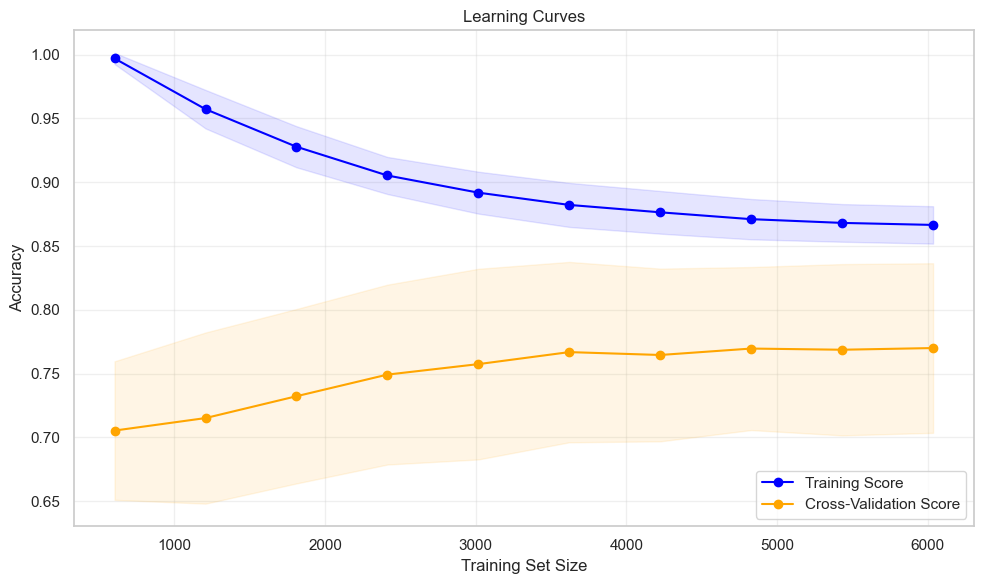


Final Training Accuracy: 0.8666 +/- 0.0147
Final CV Accuracy: 0.7701 +/- 0.0664
Generalization Gap: 0.0965


In [ ]:
from sklearn.model_selection import learning_curve

print("Generating Learning Curves...")

train_sizes, train_scores, val_scores = learning_curve(
    final_model,
    X_train,
    y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='accuracy',
    n_jobs=1,
    shuffle=True,
    random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
ax.plot(train_sizes, val_mean, 'o-', color='orange', label='Cross-Validation Score')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='orange')
ax.set_xlabel('Training Set Size')
ax.set_ylabel('Accuracy')
ax.set_title('Learning Curves')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

final_gap = train_mean[-1] - val_mean[-1]
plt.tight_layout()
plt.show()

print(f"\nFinal Training Accuracy: {train_mean[-1]:.4f} +/- {train_std[-1]:.4f}")
print(f"Final CV Accuracy: {val_mean[-1]:.4f} +/- {val_std[-1]:.4f}")
print(f"Generalization Gap: {final_gap:.4f}")
if final_gap > 0.05:
    print("Warning: Significant gap suggests possible overfitting.")
else:
    print("Model generalizes well (gap < 0.05).")

# 6. Final Model Evaluation

Performance metrics on the held-out test set using the optimized model.

Final Test Set Results
AUC:      0.8938
Accuracy: 0.8178

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83      1007
           1       0.80      0.81      0.81       881

    accuracy                           0.82      1888
   macro avg       0.82      0.82      0.82      1888
weighted avg       0.82      0.82      0.82      1888



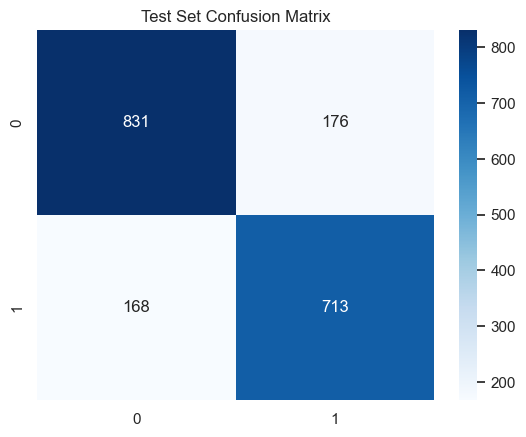

In [ ]:
y_test_pred = final_model.predict(X_test)
y_test_prob = final_model.predict_proba(X_test)[:, 1]

acc_ft  = accuracy_score(y_test, y_test_pred)
f1_ft   = f1_score(y_test, y_test_pred, zero_division=0)
prec_ft = precision_score(y_test, y_test_pred, zero_division=0)
rec_ft  = recall_score(y_test, y_test_pred, zero_division=0)
auc_ft  = roc_auc_score(y_test, y_test_prob)

print("Final Test Set Results")
print(f"Accuracy:  {acc_ft:.4f}")
print(f"F1:        {f1_ft:.4f}")
print(f"Precision: {prec_ft:.4f}")
print(f"Recall:    {rec_ft:.4f}")
print(f"AUC:       {auc_ft:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Test Set Confusion Matrix')
plt.show()


# 7. Counterfactual Analysis

Interpret model decisions by finding the nearest counterfactual examples - similar sentences with opposite classifications.

COUNTERFACTUAL ANALYSIS

Original Sentence (Classified as BIASED):
   "No matter which side of the debate table you sit at, you cannot deny the impact made by influential conservatives."


c:\Users\user\Documents\GitHub\project\inspectus-env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but VarianceThreshold was fitted with feature names
  warnings.warn(



Closest Counterfactual (Classified as NEUTRAL):
   "Data on excess deaths compared to previous years can also help reveal when coronavirus landed in a particular state."
   (Distance in feature space: 57.5345)


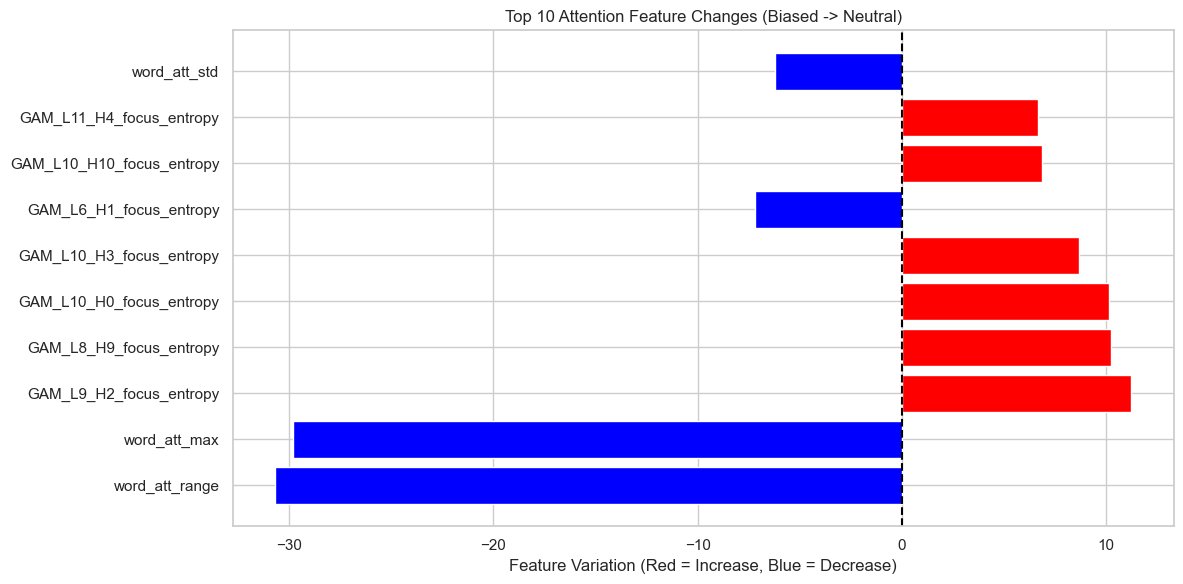

In [ ]:
from scipy.spatial.distance import euclidean

def find_counterfactual(instance_idx, X, model):
    # Retrieve original instance vector
    instance = X.loc[instance_idx].values
    # Current prediction
    current_pred = model.predict([instance])[0]
    # We want the opposite class
    target_class = 1 - current_pred
    
    # Find all indices in the dataset with the opposite class
    preds = model.predict(X)
    candidate_indices = X.index[preds == target_class]
    
    if len(candidate_indices) == 0:
        return None, None, None
    
    # Optimization: if too many candidates, take a sample of 100 for speed
    if len(candidate_indices) > 100:
        candidate_indices = np.random.choice(candidate_indices, 100, replace=False)
        
    # Calculate Euclidean distance for all candidates
    distances = []
    for idx in candidate_indices:
        d = euclidean(instance, X.loc[idx].values)
        distances.append((idx, d))
    
    # Get the closest one
    distances.sort(key=lambda x: x[1])
    best_idx, min_dist = distances[0]
    return X.loc[best_idx].values, best_idx, min_dist

print("COUNTERFACTUAL ANALYSIS")

# Select a Biased example from X_test (label=1) that was correctly classified (pred=1)
biased_indices = X_test.index[(y_test == 1) & (final_model.predict(X_test) == 1)]

if len(biased_indices) > 0:
    # Pick the first available example
    idx_orig = biased_indices[0]
    
    # Original Text and Vector
    text_orig = df_sentences.loc[idx_orig, 'text']
    vec_orig = X_test.loc[idx_orig].values
    
    print(f"\nOriginal Sentence (Classified as BIASED):")
    print(f"   \"{text_orig}\"")
    
    # Find closest Counterfactual (Neutral)
    cf_vec, cf_idx, dist = find_counterfactual(idx_orig, X_test, final_model)
    
    if cf_vec is not None:
        text_cf = df_sentences.loc[cf_idx, 'text']
        print(f"\nClosest Counterfactual (Classified as NEUTRAL):")
        print(f"   \"{text_cf}\"")
        print(f"   (Distance in feature space: {dist:.4f})")
        
        # Visualize Feature Changes
        diff = cf_vec - vec_orig
        feat_names = X_test.columns
        
        # Get top 10 absolute changes
        top_ids = np.argsort(np.abs(diff))[::-1][:10]
        
        plot_feats = [feat_names[i] for i in top_ids]
        plot_vals = [diff[i] for i in top_ids]
        
        plt.figure(figsize=(12, 6))
        colors = ['red' if v > 0 else 'blue' for v in plot_vals]
        plt.barh(plot_feats, plot_vals, color=colors)
        plt.title(f"Top 10 Attention Feature Changes (Biased -> Neutral)")
        plt.xlabel("Feature Variation (Red = Increase, Blue = Decrease)")
        plt.axvline(0, color='black', linestyle='--')
        plt.tight_layout()
        plt.show()
    else:
        print("No opposite counterfactual found in this dataset.")
else:
    print("No correctly classified biased examples found in X_test to analyze.")

EXAMPLE 2: NEUTRAL Sentence -> What would make it Biased?

Original Sentence (Classified as NEUTRAL):
   "Negotiation skills vary among individuals."

Closest Counterfactual (Classified as BIASED):
   "Productivity measures output per input."
   (Distance in feature space: 17.3008)


c:\Users\user\Documents\GitHub\project\inspectus-env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but VarianceThreshold was fitted with feature names
  warnings.warn(


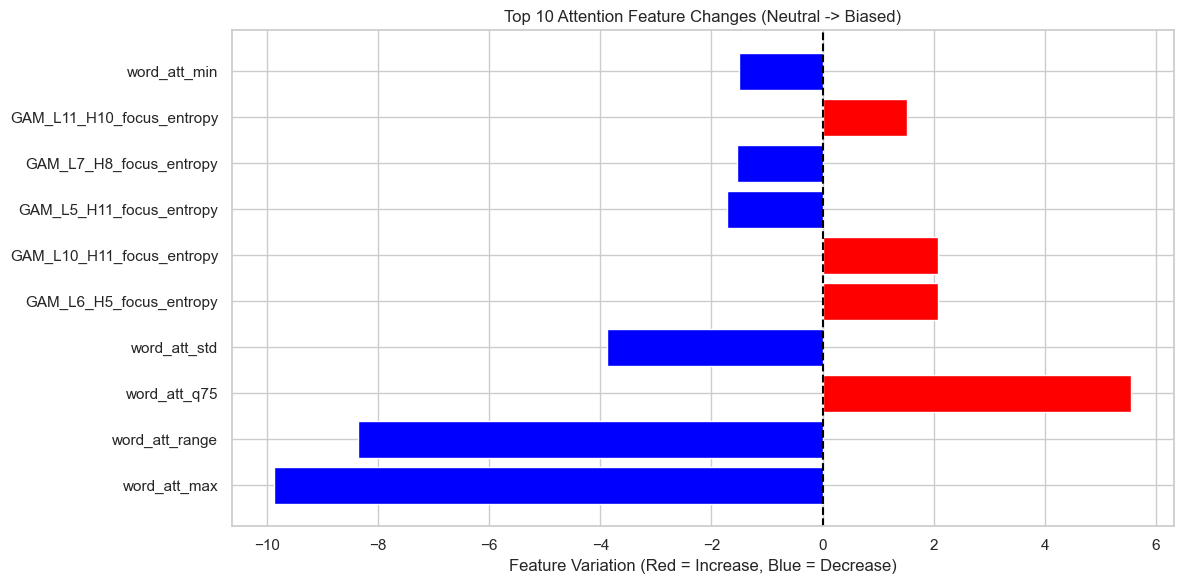

In [ ]:

print("EXAMPLE 2: NEUTRAL Sentence -> What would make it Biased?")

# Select a Neutral example from X_test (label=0) that was correctly classified (pred=0)
neutral_indices = X_test.index[(y_test == 0) & (final_model.predict(X_test) == 0)]

if len(neutral_indices) > 0:
    # Pick the first available example
    idx_orig = neutral_indices[0]
    
    # Original Text and Vector
    text_orig = df_sentences.loc[idx_orig, 'text']
    vec_orig = X_test.loc[idx_orig].values
    
    print(f"\nOriginal Sentence (Classified as NEUTRAL):")
    print(f"   \"{text_orig}\"")
    
    # Find closest Counterfactual (Biased)
    cf_vec, cf_idx, dist = find_counterfactual(idx_orig, X_test, final_model)
    
    if cf_vec is not None:
        text_cf = df_sentences.loc[cf_idx, 'text']
        print(f"\nClosest Counterfactual (Classified as BIASED):")
        print(f"   \"{text_cf}\"")
        print(f"   (Distance in feature space: {dist:.4f})")
        
        # Visualize Feature Changes
        diff = cf_vec - vec_orig
        feat_names = X_test.columns
        
        # Get top 10 absolute changes
        top_ids = np.argsort(np.abs(diff))[::-1][:10]
        
        plot_feats = [feat_names[i] for i in top_ids]
        plot_vals = [diff[i] for i in top_ids]
        
        plt.figure(figsize=(12, 6))
        colors = ['red' if v > 0 else 'blue' for v in plot_vals]
        plt.barh(plot_feats, plot_vals, color=colors)
        plt.title(f"Top 10 Attention Feature Changes (Neutral -> Biased)")
        plt.xlabel("Feature Variation (Red = Increase, Blue = Decrease)")
        plt.axvline(0, color='black', linestyle='--')
        plt.tight_layout()
        plt.show()
    else:
        print("No biased counterfactual found in this dataset.")
else:
    print("No correctly classified neutral examples found in X_test to analyze.")

# 8. Feature Importance Analysis

Model interpretation using SHAP values and permutation importance to identify which attention features contribute most to bias detection.

## 8.1 SHAP Values

Use SHAP (SHapley Additive exPlanations) to understand feature contributions to predictions.

Features after VT: 757 / 3238
SHAP (Tree)
TreeExplainer failed: Model type not yet supported by TreeExplainer: <class 'sklearn.linear_model._logistic.LogisticRegression'>. Using KernelExplainer.
SHAP (Kernel)


  0%|          | 0/1888 [00:00<?, ?it/s]

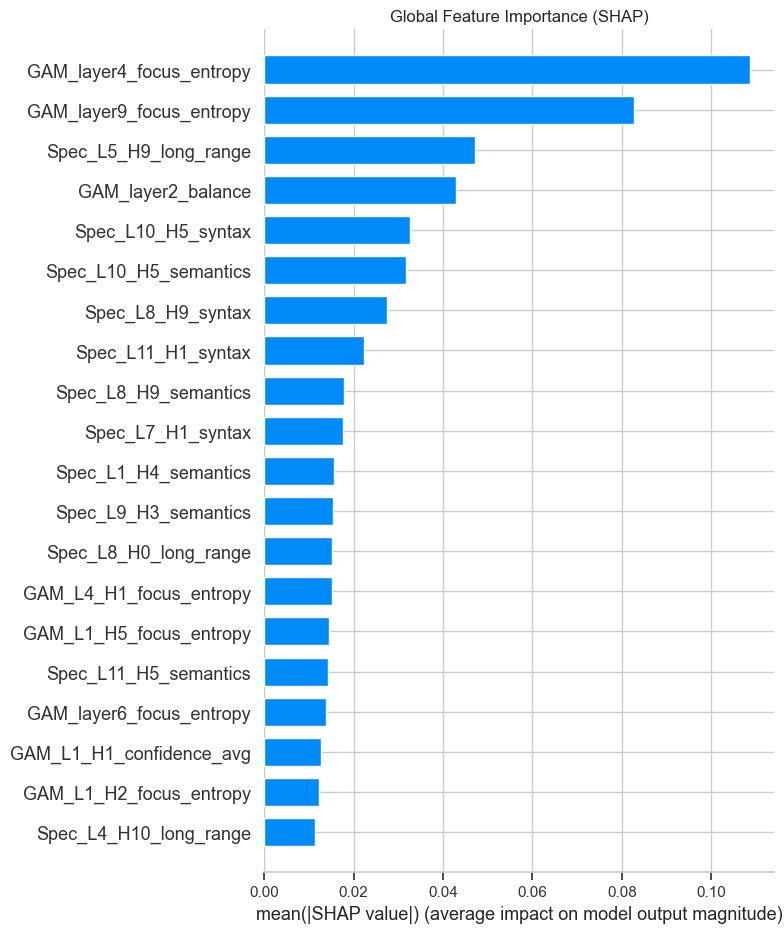

In [ ]:
import shap
import gc

# Clear memory
gc.collect()

# Extract pipeline steps
vt_step = final_model.named_steps['vt']
model_step = final_model.named_steps['m']
scaler_step = final_model.named_steps['s']
fs_step = final_model.named_steps.get('fs', None)  # SelectKBest (may not exist)

# Get selected feature names after VarianceThreshold
vt_mask = vt_step.get_support()
selected_features = X_train.columns[vt_mask]
print(f"Features after VT: {vt_mask.sum()} / {len(vt_mask)}")

# Apply SelectKBest mask if present
if fs_step is not None:
    fs_mask = fs_step.get_support()
    selected_features = selected_features[fs_mask]
    print(f"Features after SelectKBest: {fs_mask.sum()} / {len(fs_mask)}")

# Transform test data through VT (and SelectKBest if present) then Scaler
X_test_vt = vt_step.transform(X_test)
if fs_step is not None:
    X_test_vt = fs_step.transform(X_test_vt)
X_test_scaled = scaler_step.transform(X_test_vt)
X_test_df = pd.DataFrame(X_test_scaled, columns=selected_features, index=X_test.index)

X_shap = X_test_df

try:
    print("SHAP (Tree)")
    explainer = shap.TreeExplainer(model_step)
    shap_values = explainer.shap_values(X_shap)
    if isinstance(shap_values, list): shap_values = shap_values[1]

except Exception as e:
    print(f"TreeExplainer failed: {e}. Using KernelExplainer.")

    X_train_vt = vt_step.transform(X_train)
    if fs_step is not None:
        X_train_vt = fs_step.transform(X_train_vt)
    background = np.median(scaler_step.transform(X_train_vt), axis=0).reshape(1, -1)

    f = lambda x: model_step.predict_proba(x)[:, 1]
    explainer = shap.KernelExplainer(f, background)

    print("SHAP (Kernel)")
    shap_values = explainer.shap_values(X_shap, nsamples=2000)

# Plot Results
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap, plot_type="bar", show=False)
plt.title("Global Feature Importance (SHAP)")
plt.tight_layout()
plt.show()


## 8.2 Permutation Feature Importance

Measure the decrease in model accuracy when a single feature's values are randomly shuffled, breaking the relationship between the feature and the target. Computed on the held-out test set.

Calculating Permutation Feature Importance...


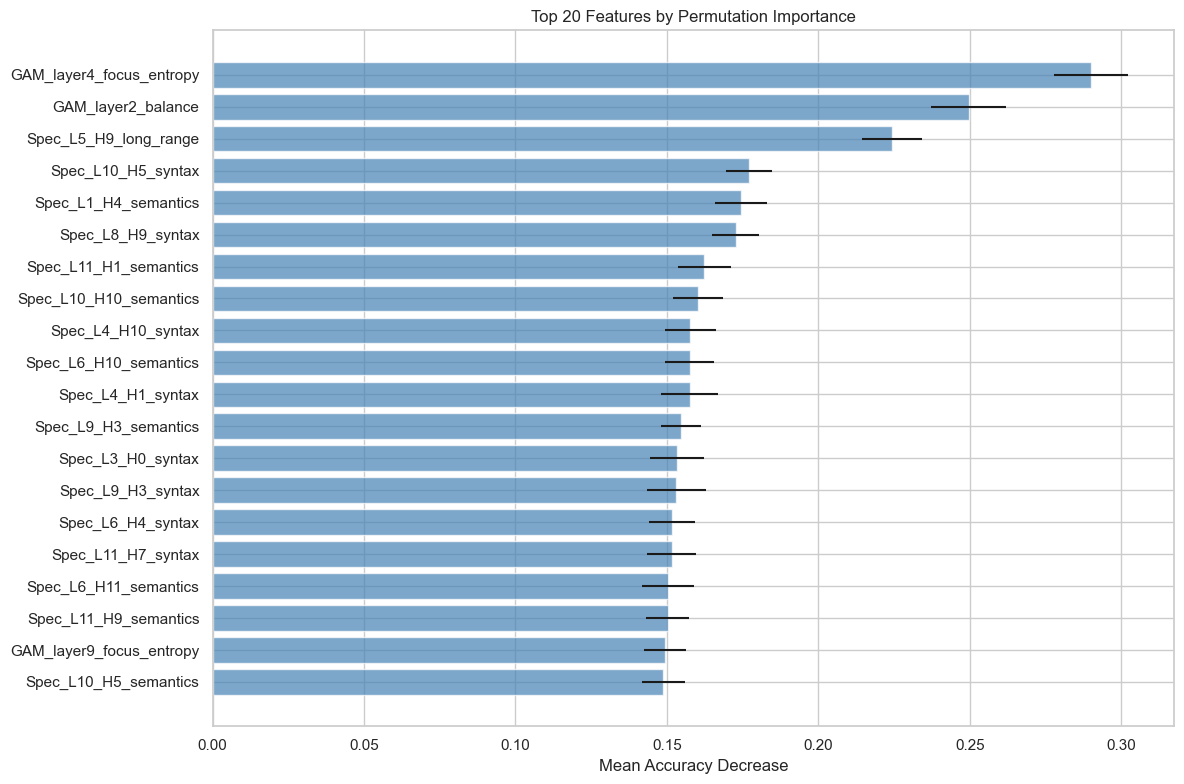


Top 10 Most Important Features:
                 Feature  Importance      Std
GAM_layer4_focus_entropy    0.290095 0.012201
      GAM_layer2_balance    0.249576 0.012305
   Spec_L5_H9_long_range    0.224206 0.009847
      Spec_L10_H5_syntax    0.177066 0.007606
    Spec_L1_H4_semantics    0.174470 0.008730
       Spec_L8_H9_syntax    0.172669 0.007712
   Spec_L11_H1_semantics    0.162394 0.008633
  Spec_L10_H10_semantics    0.160169 0.008240
      Spec_L4_H10_syntax    0.157733 0.008344
   Spec_L6_H10_semantics    0.157521 0.008019


In [ ]:
from sklearn.inspection import permutation_importance

print("Calculating Permutation Feature Importance...")

perm_importance = permutation_importance(
    final_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=1,
    scoring='accuracy'
)

perm_features_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': perm_importance.importances_mean,
    'Std': perm_importance.importances_std
})

top_perm_features = perm_features_df.sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(12, 8))
plt.barh(range(len(top_perm_features)), top_perm_features['Importance'], 
         xerr=top_perm_features['Std'], color='steelblue', alpha=0.7)
plt.yticks(range(len(top_perm_features)), top_perm_features['Feature'])
plt.xlabel('Mean Accuracy Decrease')
plt.title('Top 20 Features by Permutation Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nTop 10 Most Important Features:")
print(top_perm_features.head(10).to_string(index=False))

## 8.3 Feature Stability Analysis

Assess the stability of top features across multiple permutation runs to ensure they are not artifacts of a specific random seed.

In [ ]:
print("Analyzing Feature Stability across multiple runs...")

n_runs = 5
all_importances = []

for run in range(n_runs):
    perm_run = permutation_importance(
        final_model,
        X_test,
        y_test,
        n_repeats=5,
        random_state=run * 42,
        n_jobs=1,
        scoring='accuracy'
    )
    all_importances.append(perm_run.importances_mean)
    print(f"Run {run + 1}/{n_runs} completed")

importance_matrix = np.array(all_importances)
mean_importance = np.mean(importance_matrix, axis=0)
std_importance = np.std(importance_matrix, axis=0)
cv_importance = std_importance / (mean_importance + 1e-10)

stability_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean_Importance': mean_importance,
    'Std_Importance': std_importance,
    'CV': cv_importance
}).sort_values('Mean_Importance', ascending=False)

top_20_stable = stability_df.head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].barh(range(len(top_20_stable)), top_20_stable['Mean_Importance'],
             xerr=top_20_stable['Std_Importance'], color='steelblue', alpha=0.7)
axes[0].set_yticks(range(len(top_20_stable)))
axes[0].set_yticklabels(top_20_stable['Feature'], fontsize=9)
axes[0].set_xlabel('Mean Importance')
axes[0].set_title('Top 20 Features with Stability Error Bars')
axes[0].invert_yaxis()

axes[1].scatter(top_20_stable['Mean_Importance'], top_20_stable['CV'], 
                s=100, alpha=0.7, c='steelblue')
for i, row in top_20_stable.iterrows():
    if row['CV'] < 0.5:
        axes[1].annotate(row['Feature'][:15], (row['Mean_Importance'], row['CV']), 
                         fontsize=7, alpha=0.7)
axes[1].set_xlabel('Mean Importance')
axes[1].set_ylabel('Coefficient of Variation')
axes[1].set_title('Importance vs Stability (lower CV = more stable)')
axes[1].axhline(y=0.5, color='red', linestyle='--', label='CV = 0.5 threshold')
axes[1].legend()

plt.tight_layout()
plt.show()

stable_features = stability_df[stability_df['CV'] < 0.5].head(20)
print(f"\nMost Stable Important Features (CV < 0.5):")
print(stable_features[['Feature', 'Mean_Importance', 'CV']].head(10).to_string(index=False))

Analyzing Feature Stability across multiple runs...
Run 1/5 completed


╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:7                                                                                    │
│                                                                                                  │
│    4 all_importances = []                                                                        │
│    5                                                                                             │
│    6 for run in range(n_runs):                                                                   │
│ ❱  7 │   perm_run = permutation_importance(                                                      │
│    8 │   │   final_model,                                                                        │
│    9 │   │   X_test,                                                                             │
│   10 │   │   y_test,                                                                             │
│                                                                                                  │
│ c:\Users\user\Documents\GitHub\project\inspectus-env\Lib\site-packages\sklearn\utils\_p │
│ aram_validation.py:218 in wrapper                                                                │
│                                                                                                  │
│   215 │   │   │   │   │   │   prefer_skip_nested_validation or global_skip_validation            │
│   216 │   │   │   │   │   )                                                                      │
│   217 │   │   │   │   ):                                                                         │
│ ❱ 218 │   │   │   │   │   return func(*args, **kwargs)                                           │
│   219 │   │   │   except InvalidParameterError as e:                                             │
│   220 │   │   │   │   # When the function is just a wrapper around an estimator, we allow        │
│   221 │   │   │   │   # the function to delegate validation to the estimator, but we replace     │
│                                                                                                  │
│ c:\Users\user\Documents\GitHub\project\inspectus-env\Lib\site-packages\sklearn\inspecti │
│ on\_permutation_importance.py:288 in permutation_importance                                      │
│                                                                                                  │
│   285 │   scorer = check_scoring(estimator, scoring=scoring)                                     │
│   286 │   baseline_score = _weights_scorer(scorer, estimator, X, y, sample_weight)               │
│   287 │                                                                                          │
│ ❱ 288 │   scores = Parallel(n_jobs=n_jobs)(                                                      │
│   289 │   │   delayed(_calculate_permutation_scores)(                                            │
│   290 │   │   │   estimator,                                                                     │
│   291 │   │   │   X,                                                                             │
│                                                                                                  │
│ c:\Users\user\Documents\GitHub\project\inspectus-env\Lib\site-packages\sklearn\utils\pa │
│ rallel.py:82 in __call__                                                                         │
│                                                                                                  │
│    79 │   │   │   )                                                                              │
│    80 │   │   │   for delayed_func, args, kwargs in iterable                                     │
│    81 │   │   )                                                                                  │
│ ❱  82 │   │   return super().__call__(iterable_with_config_and_warning_filters)       

Extracting feature importance from: LogisticRegression
Features used by model: 757
  Using model coefficients

Top 50 most important features
rank   feature                                                 importance      direction    method
----------------------------------------------------------------------------------------------------
1      GAM_layer4_focus_entropy                                    8.135903   positive     coefficients
2      GAM_layer9_focus_entropy                                    7.135174   negative     coefficients
3      Spec_L10_H5_semantics                                       5.050708   positive     coefficients
4      Spec_L10_H5_syntax                                          4.976544   positive     coefficients
5      Spec_L11_H1_syntax                                          4.584091   negative     coefficients
6      Spec_L8_H9_syntax                                           4.485196   positive     coefficients
7      Spec_L5_H9_long_range      

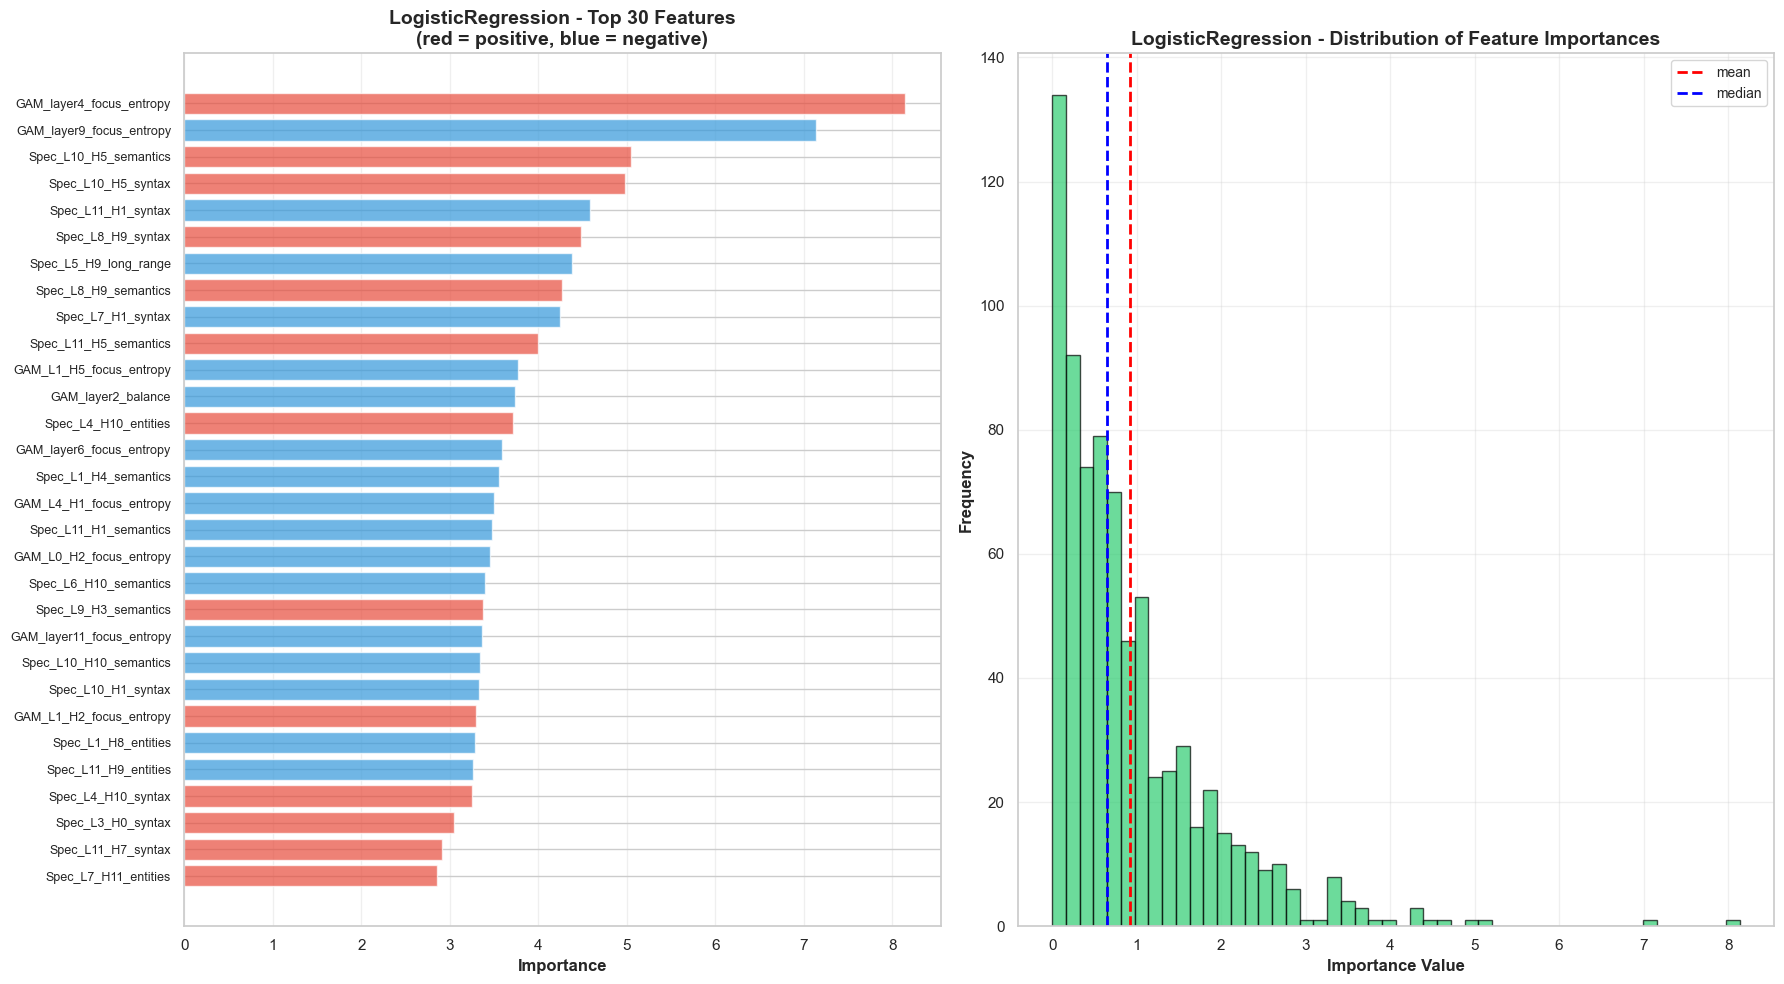


Feature importance saved to: c:\Users\user\Documents\GitHub\project\attention_app\bias\feature_importance_logisticregression.csv

Feature Type Breakdown (top 100)
  Spec (head specialization)           75 features ( 75.0%)
  GAM (global attention)               25 features ( 25.0%)

Feature importance analysis complete


9

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc

def extract_feature_importance(pipeline_model, X_test, y_test=None):
    """
    Extract feature importance from sklearn pipeline.
    Handles pipelines with VarianceThreshold and SelectKBest steps.
    """
    gc.collect()

    model_step = pipeline_model.named_steps['m']

    # Get feature names after VT (if present)
    if 'vt' in pipeline_model.named_steps:
        vt_step = pipeline_model.named_steps['vt']
        vt_mask = vt_step.get_support()
        feature_names = X_test.columns[vt_mask].tolist()
    else:
        feature_names = X_test.columns.tolist()

    # Apply SelectKBest mask if present
    if 'fs' in pipeline_model.named_steps:
        fs_step = pipeline_model.named_steps['fs']
        fs_mask = fs_step.get_support()
        feature_names = [f for f, m in zip(feature_names, fs_mask) if m]

    model_type = type(model_step).__name__
    print(f"Extracting feature importance from: {model_type}")
    print(f"Features used by model: {len(feature_names)}")

    # Coefficients (logistic regression, linear SVC, etc.)
    if hasattr(model_step, 'coef_'):
        print("  Using model coefficients")
        coef = model_step.coef_[0] if model_step.coef_.ndim > 1 else model_step.coef_
        importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': np.abs(coef),
            'Raw_Coefficient': coef,
            'Direction': ['positive' if c > 0 else 'negative' for c in coef]
        })
        importance_df['Method'] = 'coefficients'

    # Feature importances (random forest, xgboost, etc.)
    elif hasattr(model_step, 'feature_importances_'):
        print("  Using feature_importances (gini/gain)")
        importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': model_step.feature_importances_,
            'Raw_Coefficient': model_step.feature_importances_,
            'Direction': ['n/a' for _ in feature_names]
        })
        importance_df['Method'] = 'impurity'

    # MLP weights from first layer
    elif hasattr(model_step, 'coefs_') and len(model_step.coefs_) > 0:
        print("  Using first layer weights (MLP)")
        first_layer_weights = model_step.coefs_[0]
        importance = np.mean(np.abs(first_layer_weights), axis=1)
        importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': importance,
            'Raw_Coefficient': importance,
            'Direction': ['n/a' for _ in feature_names]
        })
        importance_df['Method'] = 'mlp_weights'

    else:
        print("  No direct importance method available, using uniform")
        importance = np.ones(len(feature_names)) / len(feature_names)
        importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': importance,
            'Raw_Coefficient': importance,
            'Direction': ['n/a' for _ in feature_names]
        })
        importance_df['Method'] = 'uniform_fallback'

    importance_df = importance_df.sort_values('Importance', ascending=False).reset_index(drop=True)
    gc.collect()
    return importance_df, model_type


# Extract importance from best model
feature_importance_df, model_name_imp = extract_feature_importance(
    pipeline_model=final_model,
    X_test=X_test,
    y_test=y_test
)

# Display top 50
print("\nTop 50 most important features")
print(f"{'rank':<6} {'feature':<55} {'importance':<15} {'direction':<12} {'method'}")
print("-"*100)

for idx, row in feature_importance_df.head(50).iterrows():
    print(f"{idx+1:<6} {row['Feature']:<55} {row['Importance']:>12.6f}   {row['Direction']:<12} {row['Method']}")

# Summary statistics
print("\nSummary Statistics")
print(f"Model type:         {model_name_imp}")
print(f"Importance method:  {feature_importance_df['Method'].iloc[0]}")
print(f"Total features:     {len(feature_importance_df)}")
print(f"Max importance:     {feature_importance_df['Importance'].max():.6f}")
print(f"Min importance:     {feature_importance_df['Importance'].min():.6f}")
print(f"Mean importance:    {feature_importance_df['Importance'].mean():.6f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

top_30 = feature_importance_df.head(30)

if 'positive' in str(feature_importance_df['Direction'].iloc[0]):
    colors = ['#e74c3c' if 'positive' in d else '#3498db' for d in top_30['Direction']]
    title_suffix = '\n(red = positive, blue = negative)'
else:
    colors = '#2ecc71'
    title_suffix = ''

axes[0].barh(range(len(top_30)), top_30['Importance'], color=colors, alpha=0.7)
axes[0].set_yticks(range(len(top_30)))
axes[0].set_yticklabels(top_30['Feature'], fontsize=9)
axes[0].set_xlabel('Importance', fontsize=12, fontweight='bold')
axes[0].set_title(f'{model_name_imp} - Top 30 Features{title_suffix}', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

axes[1].hist(feature_importance_df['Importance'], bins=50, edgecolor='black', alpha=0.7, color='#2ecc71')
axes[1].axvline(x=feature_importance_df['Importance'].mean(), color='red', linestyle='--', linewidth=2, label='mean')
axes[1].axvline(x=feature_importance_df['Importance'].median(), color='blue', linestyle='--', linewidth=2, label='median')
axes[1].set_xlabel('Importance Value', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1].set_title(f'{model_name_imp} - Distribution of Feature Importances', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Save results
output_path = os.path.join(root_dir, 'attention_app', 'bias', f'feature_importance_{model_name_imp.lower()}.csv')
feature_importance_df.to_csv(output_path, index=False)
print(f"\nFeature importance saved to: {output_path}")

# Feature type breakdown
print("\nFeature Type Breakdown (top 100)")
top_100_features = feature_importance_df.head(100)['Feature']

feature_types = {
    'GAM (global attention)': 0,
    'Spec (head specialization)': 0,
    'ISA (inter-sentence)': 0,
    'Tree (dependency)': 0,
    'AttMap (raw attention)': 0,
    'Word (word attention stats)': 0,
    'Other': 0
}

for feat in top_100_features:
    if feat.startswith('GAM'):
        feature_types['GAM (global attention)'] += 1
    elif feat.startswith('Spec'):
        feature_types['Spec (head specialization)'] += 1
    elif feat.startswith('ISA'):
        feature_types['ISA (inter-sentence)'] += 1
    elif feat.startswith('Tree'):
        feature_types['Tree (dependency)'] += 1
    elif feat.startswith('AttMap'):
        feature_types['AttMap (raw attention)'] += 1
    elif feat.startswith('word_att'):
        feature_types['Word (word attention stats)'] += 1
    else:
        feature_types['Other'] += 1

for feat_type, count in sorted(feature_types.items(), key=lambda x: x[1], reverse=True):
    if count > 0:
        pct = (count / 100) * 100
        print(f"  {feat_type:<35} {count:>3} features ({pct:>5.1f}%)")

print("\nFeature importance analysis complete")
gc.collect()


cumulative importance analysis

features needed for cumulative importance:
  80%: 330 features
  90%: 440 features
  95%: 522 features
  rfecv optimal: 195 features (61.08% cumulative)


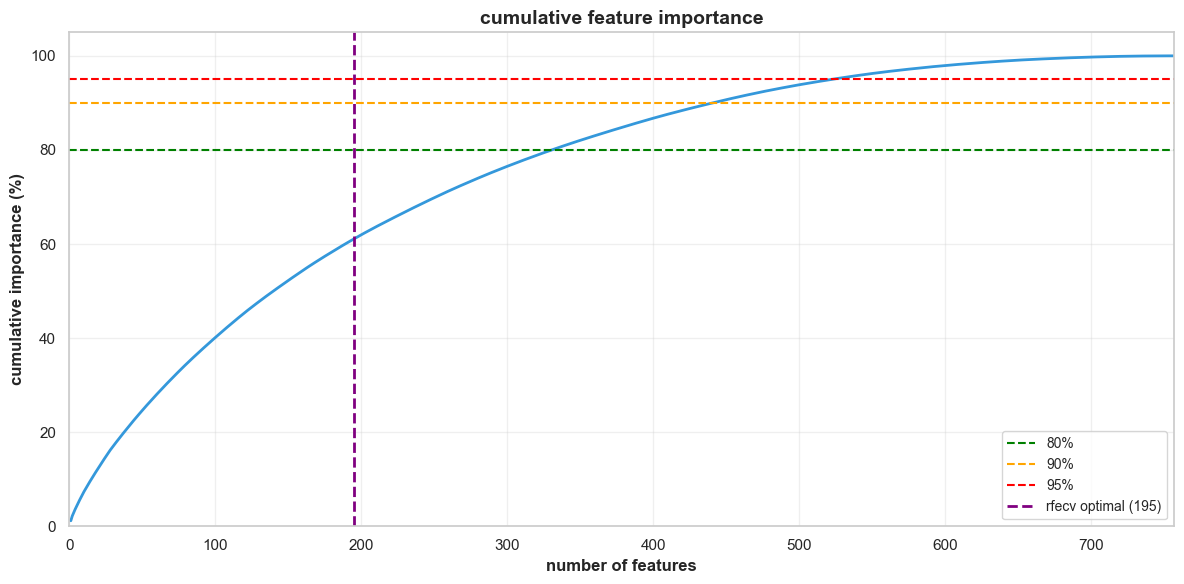

In [ ]:
# cumulative importance analysis
print("cumulative importance analysis")

# calculate cumulative importance
feature_importance_sorted = feature_importance_df.sort_values('Importance', ascending=False)
total_importance = feature_importance_sorted['Importance'].sum()
feature_importance_sorted['Cumulative_Importance'] = (
    feature_importance_sorted['Importance'].cumsum() / total_importance * 100
)

# find how many features for 80%, 90%, 95%
n_80 = (feature_importance_sorted['Cumulative_Importance'] <= 80).sum()
n_90 = (feature_importance_sorted['Cumulative_Importance'] <= 90).sum()
n_95 = (feature_importance_sorted['Cumulative_Importance'] <= 95).sum()

print(f"\nfeatures needed for cumulative importance:")
print(f"  80%: {n_80} features")
print(f"  90%: {n_90} features")
print(f"  95%: {n_95} features")
print(f"  rfecv optimal: 195 features ({feature_importance_sorted.iloc[194]['Cumulative_Importance']:.2f}% cumulative)")

# visualization
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(range(1, len(feature_importance_sorted) + 1), 
        feature_importance_sorted['Cumulative_Importance'].values,
        linewidth=2, color='#3498db')

ax.axhline(y=80, color='green', linestyle='--', linewidth=1.5, label='80%')
ax.axhline(y=90, color='orange', linestyle='--', linewidth=1.5, label='90%')
ax.axhline(y=95, color='red', linestyle='--', linewidth=1.5, label='95%')
ax.axvline(x=195, color='purple', linestyle='--', linewidth=2, label='rfecv optimal (195)')

ax.set_xlabel('number of features', fontsize=12, fontweight='bold')
ax.set_ylabel('cumulative importance (%)', fontsize=12, fontweight='bold')
ax.set_title('cumulative feature importance', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim(0, len(feature_importance_sorted))
ax.set_ylim(0, 105)

plt.tight_layout()
plt.show()

## 8.4 Consensus Feature Ranking

Average rankings from multiple feature importance methods to identify the most robustly important features.

Features ranked by importance: 757
Features ranked by SHAP: 757

COMPLETE CONSENSUS RANKING
Top 20 features by consensus:
                 Feature  Consensus_Rank  Importance_Rank  SHAP_Rank
GAM_layer4_focus_entropy             1.0              1.0        1.0
GAM_layer9_focus_entropy             2.0              2.0        2.0
   Spec_L10_H5_semantics             4.5              3.0        6.0
      Spec_L10_H5_syntax             4.5              4.0        5.0
   Spec_L5_H9_long_range             5.0              7.0        3.0
      Spec_L11_H1_syntax             6.5              5.0        8.0
       Spec_L8_H9_syntax             6.5              6.0        7.0
      GAM_layer2_balance             8.0             12.0        4.0
    Spec_L8_H9_semantics             8.5              8.0        9.0
       Spec_L7_H1_syntax             9.5              9.0       10.0
 GAM_L1_H5_focus_entropy            13.0             11.0       15.0
   Spec_L11_H5_semantics            13.0          

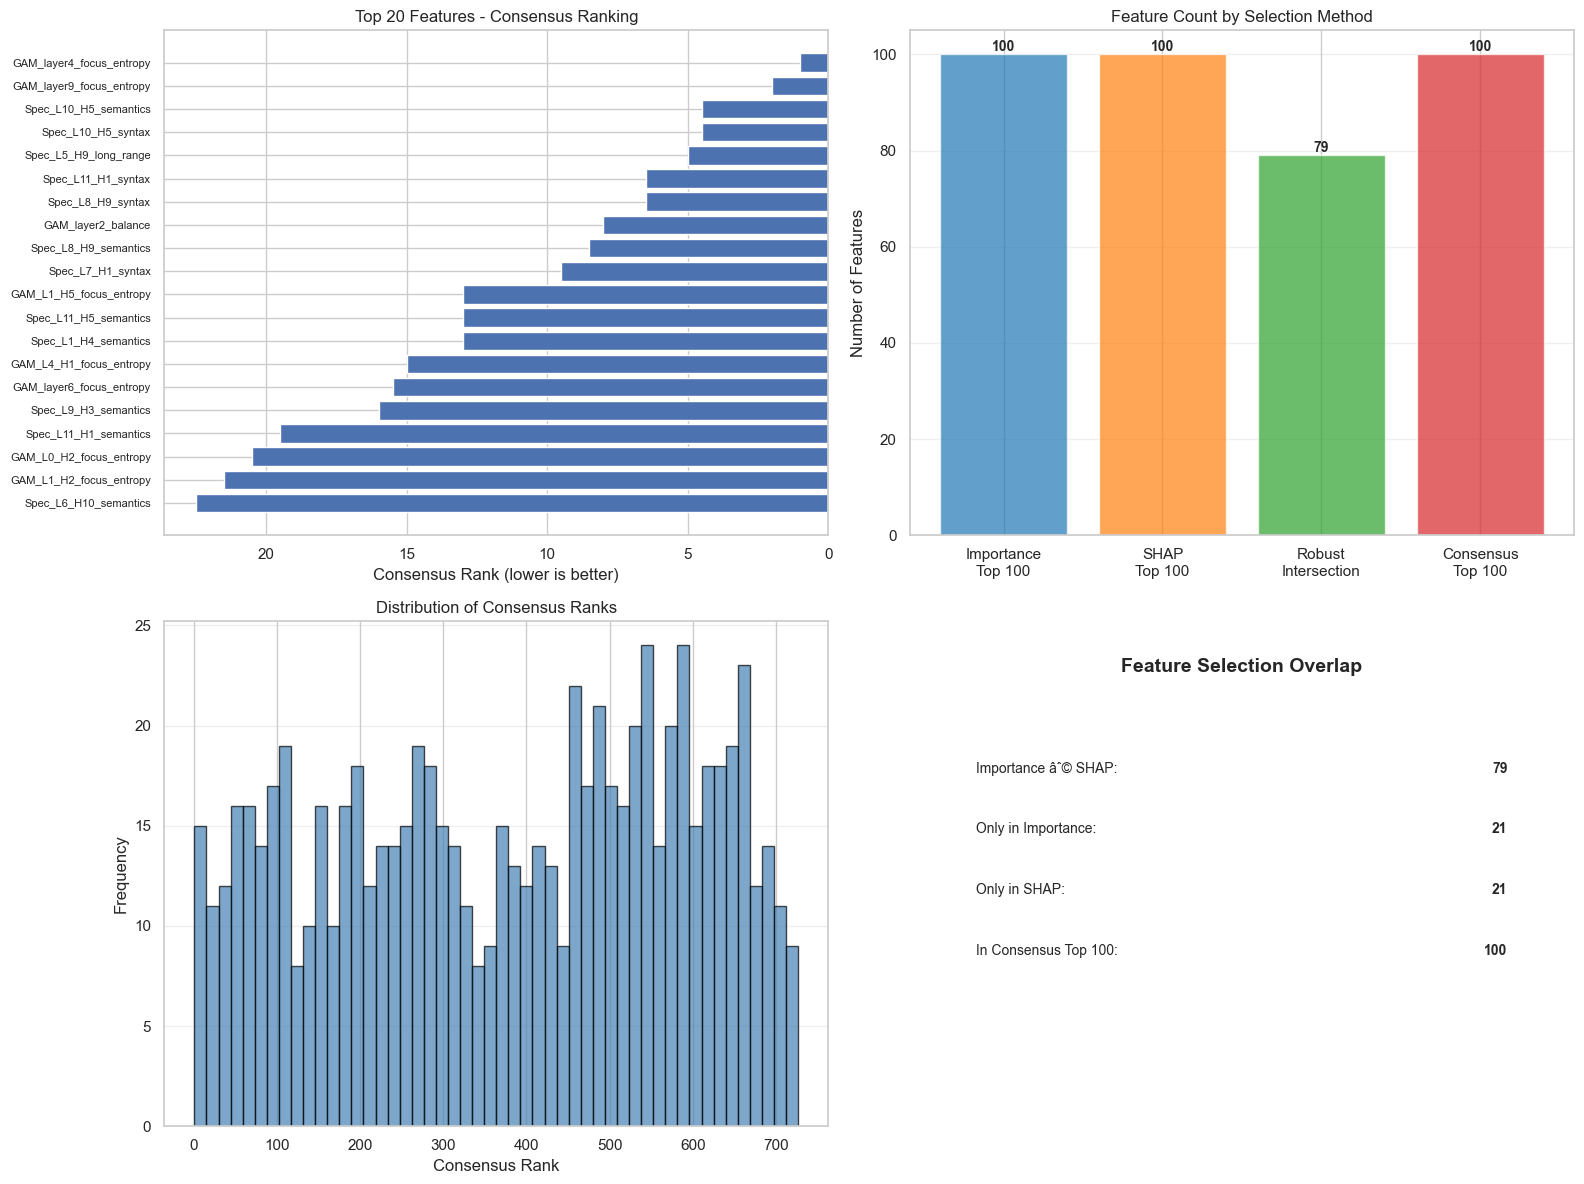


Consensus ranking analysis complete!


In [ ]:

# RANKING CONSENSUS 
# Combines rankings from: Feature Importance + SHAP

# RANKING BY FEATURE IMPORTANCE
importance_scores = dict(zip(feature_importance_df['Feature'], 
                             feature_importance_df['Importance']))
importance_rank = feature_importance_df.set_index('Feature')['Importance'].rank(
    ascending=False, method='min'
).to_dict()

print(f"Features ranked by importance: {len(importance_rank)}")


# RANKING BY SHAP
# Mean absolute SHAP values for each feature
mean_abs_shap = np.mean(np.abs(shap_values), axis=0)
shap_importance_df = pd.DataFrame({
    'Feature': X_shap.columns,
    'SHAP_Importance': mean_abs_shap
}).sort_values('SHAP_Importance', ascending=False)

shap_rank = shap_importance_df.set_index('Feature')['SHAP_Importance'].rank(
    ascending=False, method='min'
).to_dict()

print(f"Features ranked by SHAP: {len(shap_rank)}")


# CONSENSUS RANKING (Average of 2 rankings)
all_features = set(importance_rank.keys()) | set(shap_rank.keys())

consensus_scores = {}
for feat in all_features:
    ranks = []
    if feat in importance_rank:
        ranks.append(importance_rank[feat])
    if feat in shap_rank:
        ranks.append(shap_rank[feat])
    
    # Average of available ranks
    consensus_scores[feat] = np.mean(ranks) if ranks else float('inf')

# Sort by consensus score (lower = better)
consensus_df = pd.DataFrame([
    {'Feature': feat, 'Consensus_Rank': score}
    for feat, score in consensus_scores.items()
]).sort_values('Consensus_Rank')

# Add individual ranking information
consensus_df['Importance_Rank'] = consensus_df['Feature'].map(importance_rank)
consensus_df['SHAP_Rank'] = consensus_df['Feature'].map(shap_rank)

print(f"\nCOMPLETE CONSENSUS RANKING")
print(f"Top 20 features by consensus:")
print(consensus_df.head(20).to_string(index=False))


# EXTRACT TOP FEATURES BY EACH METHOD
top_100_importance = feature_importance_df.head(100)['Feature'].tolist()
top_100_shap = shap_importance_df.head(100)['Feature'].tolist()
top_100_consensus = consensus_df.head(100)['Feature'].tolist()

# Robust intersection (features in both importance and SHAP top 100)
robust_features = [f for f in top_100_importance if f in top_100_shap]

print(f"METHODS SUMMARY")
print(f"Method 1 - Top 100 by Importance:    {len(top_100_importance)}")
print(f"Method 2 - Top 100 by SHAP:          {len(top_100_shap)}")
print(f"Method 3 - Robust (Intersection):    {len(robust_features)}")
print(f"Method 4 - Top 100 by Consensus:     {len(top_100_consensus)}")


# VISUALIZATION

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

#Top 20 Consensus
ax1 = axes[0, 0]
top_20_consensus = consensus_df.head(20)
ax1.barh(range(len(top_20_consensus)), top_20_consensus['Consensus_Rank'])
ax1.set_yticks(range(len(top_20_consensus)))
ax1.set_yticklabels(top_20_consensus['Feature'], fontsize=8)
ax1.set_xlabel('Consensus Rank (lower is better)')
ax1.set_title('Top 20 Features - Consensus Ranking')
ax1.invert_yaxis()
ax1.invert_xaxis()

# Size comparison
ax2 = axes[0, 1]
methods = ['Importance\nTop 100', 'SHAP\nTop 100', 'Robust\nIntersection', 'Consensus\nTop 100']
counts = [len(top_100_importance), len(top_100_shap), len(robust_features), len(top_100_consensus)]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bars = ax2.bar(methods, counts, color=colors, alpha=0.7)
ax2.set_ylabel('Number of Features')
ax2.set_title('Feature Count by Selection Method')
ax2.grid(axis='y', alpha=0.3)
for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(count)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Consensus Ranks distribution
ax3 = axes[1, 0]
ax3.hist(consensus_df['Consensus_Rank'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
ax3.set_xlabel('Consensus Rank')
ax3.set_ylabel('Frequency')
ax3.set_title('Distribution of Consensus Ranks')
ax3.grid(axis='y', alpha=0.3)

# Methods overlap
ax4 = axes[1, 1]
ax4.text(0.5, 0.9, 'Feature Selection Overlap', ha='center', fontsize=14, fontweight='bold')

overlaps = [
    ('Importance âˆ© SHAP', len(robust_features)),
    ('Only in Importance', len([f for f in top_100_importance if f not in top_100_shap])),
    ('Only in SHAP', len([f for f in top_100_shap if f not in top_100_importance])),
    ('In Consensus Top 100', len(top_100_consensus)),
]

y_pos = 0.7
for label, count in overlaps:
    ax4.text(0.1, y_pos, f'{label}:', fontsize=10)
    ax4.text(0.9, y_pos, f'{count}', fontsize=10, fontweight='bold', ha='right')
    y_pos -= 0.12

ax4.set_xlim(0, 1)
ax4.set_ylim(0, 1)
ax4.axis('off')

plt.tight_layout()
plt.show()

print(f"\nConsensus ranking analysis complete!")

## 8.5 Performance vs Number of Features (K)

Evaluate model performance across different numbers of top features to find the smallest K within 1% of the peak.
Features are selected using ANOVA F-test (SelectKBest) inside the pipeline, with group-aware cross-validation.

Evaluating Performance vs Number of Features (K)...
  K=  10: Acc=0.6374 | AUC=0.7031 | F1=0.6380
  K=  20: Acc=0.6421 | AUC=0.7173 | F1=0.6361
  K=  50: Acc=0.6831 | AUC=0.7540 | F1=0.6816
  K=  75: Acc=0.6937 | AUC=0.7688 | F1=0.6927
  K= 100: Acc=0.7163 | AUC=0.7906 | F1=0.7164
  K= 150: Acc=0.7362 | AUC=0.8122 | F1=0.7376
  K= 200: Acc=0.7654 | AUC=0.8447 | F1=0.7662
  K= 300: Acc=0.8044 | AUC=0.8774 | F1=0.8003
  K= 500: Acc=0.8057 | AUC=0.8857 | F1=0.8010
  K= 750: Acc=0.8074 | AUC=0.8864 | F1=0.8021
  K= 757: Acc=0.8084 | AUC=0.8862 | F1=0.8032

Best AUC: 0.8864
1% threshold: 0.8775
Optimal K (smallest within 1% of best): 500


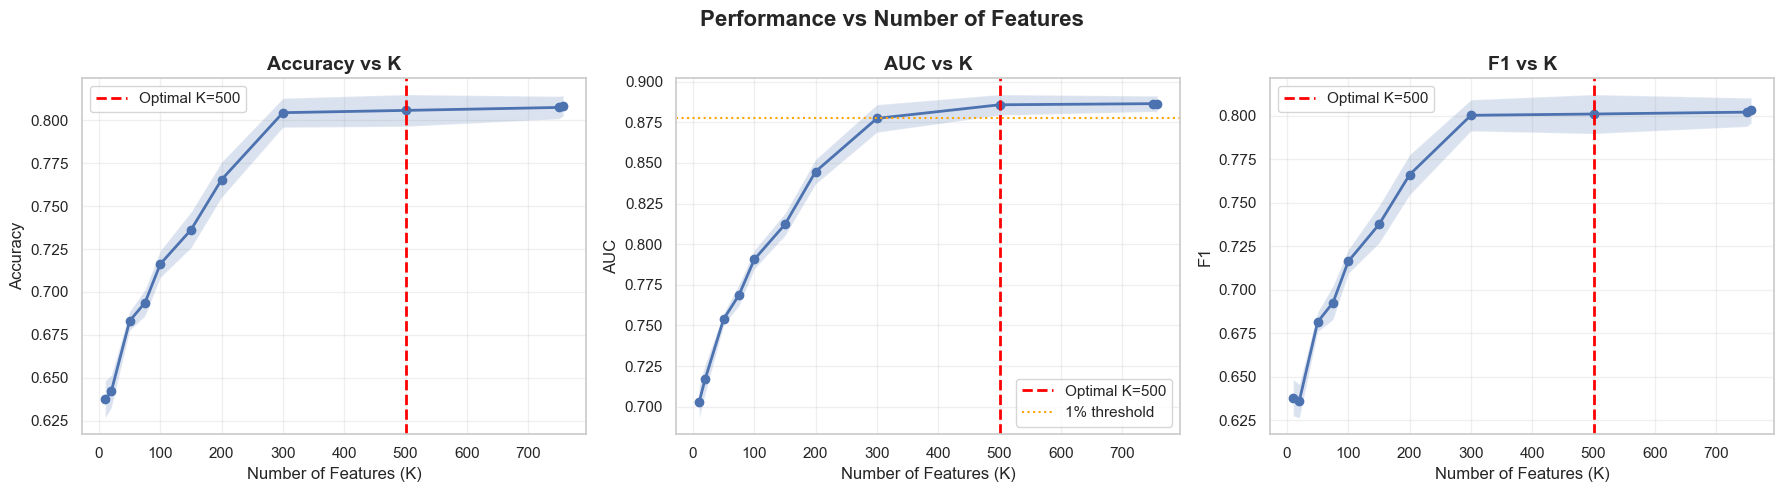


Retraining final model with SelectKBest(k=500)...
Refined Model (K=500) Test Performance:
  Accuracy: 0.8114
  AUC:      0.8910
  Features used: 500 (down from 757 after VT)


In [ ]:
# Performance vs K: find optimal number of features
print("Evaluating Performance vs Number of Features (K)...")

# Use the best model type from earlier comparison
best_model_cls = models[best_model_name]

# K values to evaluate
n_features_after_vt = final_model.named_steps['vt'].get_support().sum()
k_values = sorted(set([10, 20, 50, 75, 100, 150, 200, 300, 500,
                        min(750, n_features_after_vt),
                        n_features_after_vt]))
k_values = [k for k in k_values if k <= n_features_after_vt]

cv_k = StratifiedGroupKFold(n_splits=5)
k_results = []

for k in k_values:
    # Pipeline: VT -> SelectKBest(k) -> Scaler -> Model
    if k == n_features_after_vt:
        pipe_k = Pipeline([
            ('vt', VarianceThreshold(threshold=0.01)),
            ('s', StandardScaler()),
            ('m', clone(best_model_cls))
        ])
    else:
        pipe_k = Pipeline([
            ('vt', VarianceThreshold(threshold=0.01)),
            ('fs', SelectKBest(f_classif, k=k)),
            ('s', StandardScaler()),
            ('m', clone(best_model_cls))
        ])

    scores = cross_validate(
        pipe_k, X_train, y_train, cv=cv_k,
        scoring=['accuracy', 'roc_auc', 'f1'],
        groups=groups_train
    )

    k_results.append({
        'K': k,
        'Accuracy': scores['test_accuracy'].mean(),
        'Accuracy_std': scores['test_accuracy'].std(),
        'AUC': scores['test_roc_auc'].mean(),
        'AUC_std': scores['test_roc_auc'].std(),
        'F1': scores['test_f1'].mean(),
        'F1_std': scores['test_f1'].std()
    })
    print(f"  K={k:>4}: Acc={scores['test_accuracy'].mean():.4f} | "
          f"AUC={scores['test_roc_auc'].mean():.4f} | "
          f"F1={scores['test_f1'].mean():.4f}")

df_k = pd.DataFrame(k_results)

# Find optimal K: smallest K within 1% of the best AUC
best_auc_k = df_k['AUC'].max()
threshold_1pct = best_auc_k * 0.99
optimal_k = df_k.loc[df_k['AUC'] >= threshold_1pct, 'K'].min()

print(f"\nBest AUC: {best_auc_k:.4f}")
print(f"1% threshold: {threshold_1pct:.4f}")
print(f"Optimal K (smallest within 1% of best): {optimal_k}")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, ['Accuracy', 'AUC', 'F1']):
    ax.plot(df_k['K'], df_k[metric], 'o-', linewidth=2, markersize=6)
    ax.fill_between(df_k['K'],
                     df_k[metric] - df_k[f'{metric}_std'],
                     df_k[metric] + df_k[f'{metric}_std'],
                     alpha=0.2)
    ax.axvline(x=optimal_k, color='red', linestyle='--', linewidth=2,
               label=f'Optimal K={optimal_k}')
    if metric == 'AUC':
        ax.axhline(y=threshold_1pct, color='orange', linestyle=':',
                    label='1% threshold')
    ax.set_xlabel('Number of Features (K)', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(f'{metric} vs K', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Performance vs Number of Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ─── Retrain final model with SelectKBest(k=optimal_k) ───
print(f"\nRetraining final model with SelectKBest(k={optimal_k})...")

# Get the best hyperparameters from the tuning step
best_params = grid.best_params_
# Extract only model params (strip the m__ prefix)
model_params = {k.replace('m__', ''): v for k, v in best_params.items() if k.startswith('m__')}

# Build the refined pipeline: VT -> SelectKBest -> Scaler -> tuned Model
refined_model = clone(best_model_cls).set_params(**model_params)
final_model = Pipeline([
    ('vt', VarianceThreshold(threshold=0.01)),
    ('fs', SelectKBest(f_classif, k=min(optimal_k, n_features_after_vt))),
    ('s', StandardScaler()),
    ('m', refined_model)
])
final_model.fit(X_train, y_train)

# Evaluate on test set
y_pred_refined = final_model.predict(X_test)
y_proba_refined = final_model.predict_proba(X_test)[:, 1]

print(f"Refined Model (K={optimal_k}) Test Performance:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_refined):.4f}")
print(f"  AUC:      {roc_auc_score(y_test, y_proba_refined):.4f}")
print(f"  Features used: {optimal_k} (down from {n_features_after_vt} after VT)")


## 8.6 Feature Stability Analysis Across Folds

Assess which features consistently appear in the top-K across cross-validation folds.
Stable features (appearing in >=70% of folds) are more reliable for interpretation.

Analyzing Feature Stability (K=500)...
  Fold 1: 500 features selected
  Fold 2: 500 features selected
  Fold 3: 500 features selected
  Fold 4: 500 features selected
  Fold 5: 500 features selected

Stability Results:
  Total unique features across folds: 512
  Stable features (>=70% folds): 495
  Features in ALL folds (100%): 480


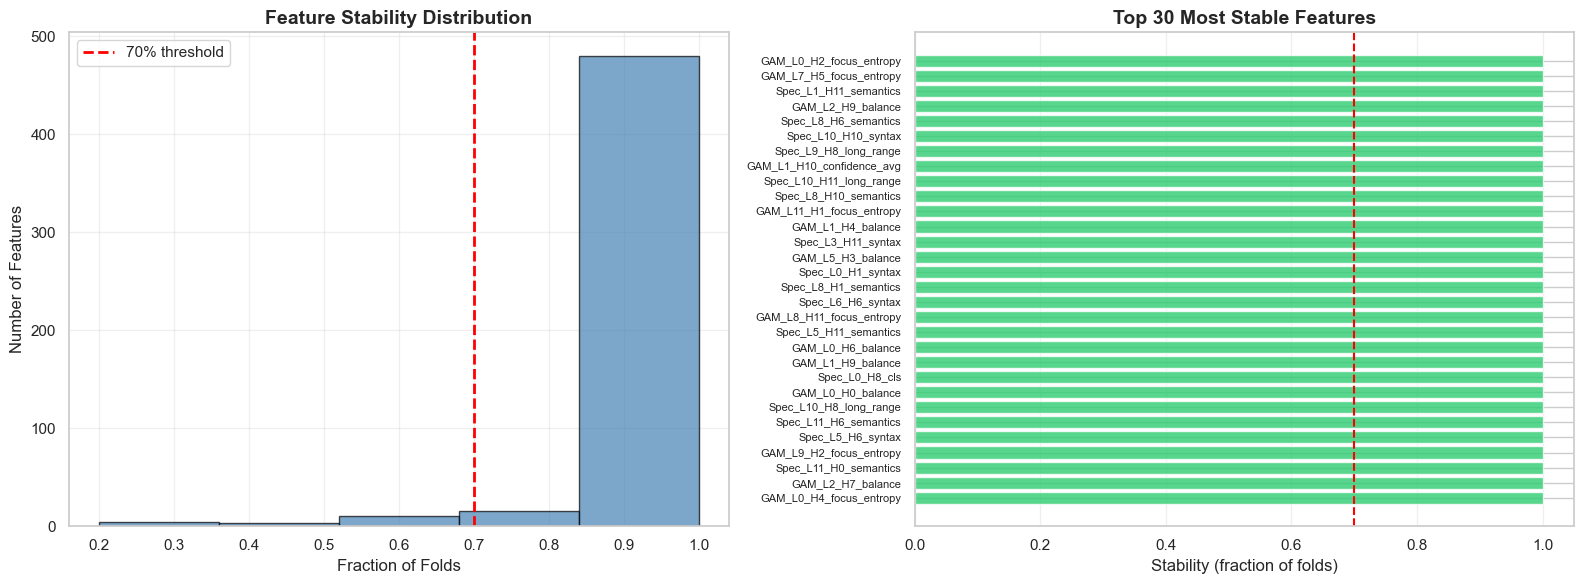


Top 20 Stable Features:
  GAM_L0_H2_focus_entropy                                 100% (5/5 folds)
  GAM_L7_H5_focus_entropy                                 100% (5/5 folds)
  Spec_L1_H11_semantics                                   100% (5/5 folds)
  GAM_L2_H9_balance                                       100% (5/5 folds)
  Spec_L8_H6_semantics                                    100% (5/5 folds)
  Spec_L10_H10_syntax                                     100% (5/5 folds)
  Spec_L9_H8_long_range                                   100% (5/5 folds)
  GAM_L1_H10_confidence_avg                               100% (5/5 folds)
  Spec_L10_H11_long_range                                 100% (5/5 folds)
  Spec_L8_H10_semantics                                   100% (5/5 folds)
  GAM_L11_H1_focus_entropy                                100% (5/5 folds)
  GAM_L1_H4_balance                                       100% (5/5 folds)
  Spec_L3_H11_syntax                                      100% (5/5 folds)


In [ ]:
# Feature stability: which features appear in top-K across folds?
from sklearn.base import clone

print(f"Analyzing Feature Stability (K={optimal_k})...")

cv_stab = StratifiedGroupKFold(n_splits=5)
fold_top_features = []

for fold_idx, (tr_idx, val_idx) in enumerate(cv_stab.split(X_train, y_train, groups=groups_train)):
    X_tr_fold = X_train.iloc[tr_idx]
    y_tr_fold = y_train.iloc[tr_idx]

    # Fit VT on this fold's training data
    vt_fold = VarianceThreshold(threshold=0.01)
    X_tr_vt = vt_fold.fit_transform(X_tr_fold)
    vt_features = X_tr_fold.columns[vt_fold.get_support()]

    # Fit SelectKBest on this fold's training data
    k_actual = min(optimal_k, X_tr_vt.shape[1])
    fs_fold = SelectKBest(f_classif, k=k_actual)
    fs_fold.fit(X_tr_vt, y_tr_fold)
    selected_mask = fs_fold.get_support()
    top_k_features = set(vt_features[selected_mask])
    fold_top_features.append(top_k_features)

    print(f"  Fold {fold_idx+1}: {len(top_k_features)} features selected")

# Count how often each feature appears across folds
from collections import Counter
feature_counts = Counter()
for feat_set in fold_top_features:
    feature_counts.update(feat_set)

n_folds = len(fold_top_features)
stability_df = pd.DataFrame([
    {'Feature': feat, 'Fold_Count': count, 'Stability': count / n_folds}
    for feat, count in feature_counts.items()
]).sort_values('Stability', ascending=False)

# Stable features: appear in >= 70% of folds
stable_features = stability_df[stability_df['Stability'] >= 0.70]['Feature'].tolist()
print(f"\nStability Results:")
print(f"  Total unique features across folds: {len(stability_df)}")
print(f"  Stable features (>=70% folds): {len(stable_features)}")
print(f"  Features in ALL folds (100%): {(stability_df['Stability'] == 1.0).sum()}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Stability distribution
axes[0].hist(stability_df['Stability'], bins=n_folds, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(x=0.70, color='red', linestyle='--', linewidth=2, label='70% threshold')
axes[0].set_xlabel('Fraction of Folds', fontsize=12)
axes[0].set_ylabel('Number of Features', fontsize=12)
axes[0].set_title('Feature Stability Distribution', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Top 30 most stable features
top_stable = stability_df.head(30)
colors = ['#2ecc71' if s >= 0.70 else '#e74c3c' for s in top_stable['Stability']]
axes[1].barh(range(len(top_stable)), top_stable['Stability'], color=colors, alpha=0.8)
axes[1].set_yticks(range(len(top_stable)))
axes[1].set_yticklabels(top_stable['Feature'], fontsize=8)
axes[1].axvline(x=0.70, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Stability (fraction of folds)', fontsize=12)
axes[1].set_title('Top 30 Most Stable Features', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTop 20 Stable Features:")
for i, row in stability_df.head(20).iterrows():
    print(f"  {row['Feature']:<55} {row['Stability']:.0%} ({int(row['Fold_Count'])}/{n_folds} folds)")

## 8.7 Head-Level Importance Aggregation

Aggregate feature importances by attention head (Layer x Head) for interpretability.
This maps directly to the dashboard's Layer x Head view and facilitates the thesis narrative.

Aggregating Feature Importance by Attention Head...

Top 20 Attention Heads by Total Importance:
Layer Head  Total_Imp    Avg_Imp  #Features  #Stable
-------------------------------------------------------
   10    5    13.9467   3.486670          4        2
    4   10    11.9909   2.398170          5        4
   11    1    11.7014   2.925350          4        1
    1    7    10.4080   1.486857          7        4
    1    4    10.1717   1.453096          7        4
    4    1    10.0695   1.438506          7        4
   11    9     9.9909   1.998176          5        3
    8    9     9.5913   2.397827          4        2
   10    1     9.5259   1.905180          5        2
   11    5     8.7657   2.191436          4        2
    0    2     8.7405   1.248637          7        4
    1    5     8.6886   1.241222          7        4
    1    2     8.6382   1.234023          7        4
    9    3     8.2563   1.032040          8        5
    1    1     7.9627   1.137527          7        4

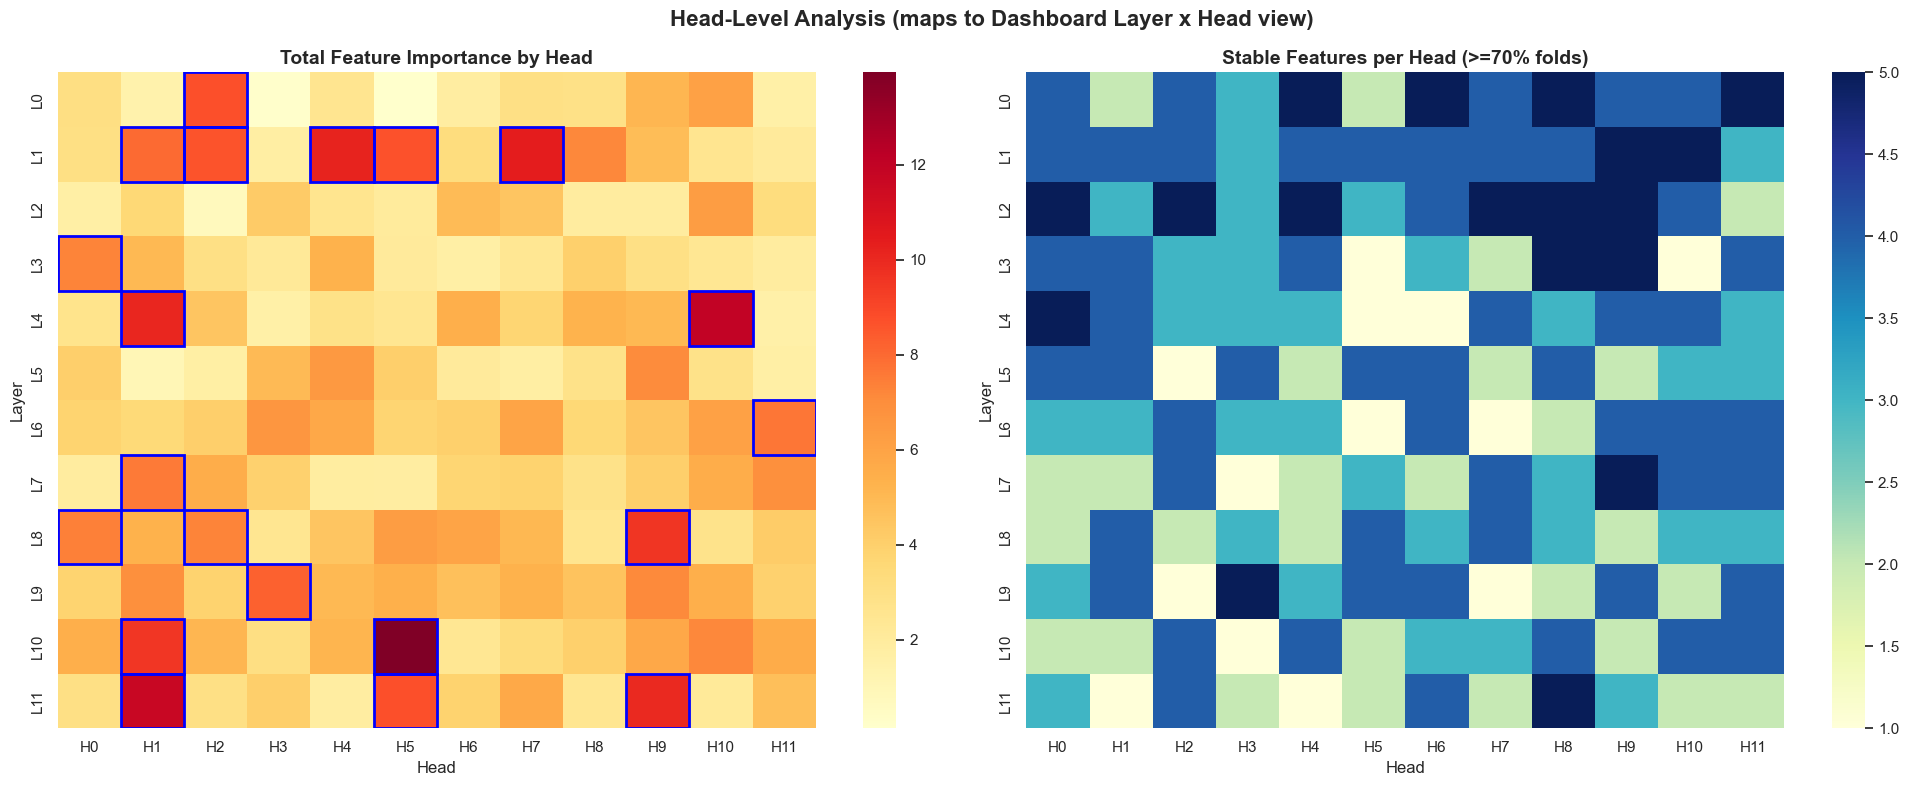


Features from Top 20 heads: 114
This maps directly to the dashboard's Layer x Head visualization.
Head importance saved to: c:\Users\user\Documents\GitHub\project\attention_app\bias\head_importance_logisticregression.csv


In [ ]:
# Head-level importance aggregation
print("Aggregating Feature Importance by Attention Head...")

def parse_head_from_feature(feature_name):
    """Extract (layer, head) from feature names like GAM_L0_H1_confidence_max."""
    match = re.match(r'(?:GAM|AttMap|Spec)_L(\d+)_H(\d+)_', feature_name)
    if match:
        return int(match.group(1)), int(match.group(2))
    return None, None

# Aggregate importances by head using the model's feature importances
head_importances = {}
head_feature_counts = {}

for _, row in feature_importance_df.iterrows():
    layer, head = parse_head_from_feature(row['Feature'])
    if layer is not None:
        key = (layer, head)
        if key not in head_importances:
            head_importances[key] = 0.0
            head_feature_counts[key] = 0
        head_importances[key] += row['Importance']
        head_feature_counts[key] += 1

# Create head importance DataFrame
head_df = pd.DataFrame([
    {'Layer': layer, 'Head': head,
     'Total_Importance': imp,
     'Avg_Importance': imp / head_feature_counts[(layer, head)],
     'Num_Features': head_feature_counts[(layer, head)]}
    for (layer, head), imp in head_importances.items()
]).sort_values('Total_Importance', ascending=False)

# Also aggregate using stable features (if available)
stable_head_counts = {}
for feat in stable_features:
    layer, head = parse_head_from_feature(feat)
    if layer is not None:
        key = (layer, head)
        stable_head_counts[key] = stable_head_counts.get(key, 0) + 1

head_df['Stable_Feature_Count'] = head_df.apply(
    lambda r: stable_head_counts.get((r['Layer'], r['Head']), 0), axis=1
)

# Select Top-M heads (10-20)
M = min(20, len(head_df))
top_heads = head_df.head(M)
print(f"\nTop {M} Attention Heads by Total Importance:")
print(f"{'Layer':>5} {'Head':>4} {'Total_Imp':>10} {'Avg_Imp':>10} {'#Features':>10} {'#Stable':>8}")
print("-" * 55)
for _, row in top_heads.iterrows():
    print(f"{int(row['Layer']):>5} {int(row['Head']):>4} {row['Total_Importance']:>10.4f} "
          f"{row['Avg_Importance']:>10.6f} {int(row['Num_Features']):>10} {int(row['Stable_Feature_Count']):>8}")

# Heatmap: Layer x Head importance
n_layers = head_df['Layer'].max() + 1
n_heads = head_df['Head'].max() + 1
heatmap_data = np.zeros((n_layers, n_heads))
for _, row in head_df.iterrows():
    heatmap_data[int(row['Layer']), int(row['Head'])] = row['Total_Importance']

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Total importance heatmap
sns.heatmap(heatmap_data, ax=axes[0], cmap='YlOrRd', annot=False,
            xticklabels=[f'H{i}' for i in range(n_heads)],
            yticklabels=[f'L{i}' for i in range(n_layers)])
axes[0].set_title('Total Feature Importance by Head', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Head', fontsize=12)
axes[0].set_ylabel('Layer', fontsize=12)

# Mark top-M heads
for _, row in top_heads.iterrows():
    axes[0].add_patch(plt.Rectangle((int(row['Head']), int(row['Layer'])), 1, 1,
                                     fill=False, edgecolor='blue', linewidth=2))

# Stable features heatmap
heatmap_stable = np.zeros((n_layers, n_heads))
for _, row in head_df.iterrows():
    heatmap_stable[int(row['Layer']), int(row['Head'])] = row['Stable_Feature_Count']

sns.heatmap(heatmap_stable, ax=axes[1], cmap='YlGnBu', annot=False,
            xticklabels=[f'H{i}' for i in range(n_heads)],
            yticklabels=[f'L{i}' for i in range(n_layers)])
axes[1].set_title('Stable Features per Head (>=70% folds)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Head', fontsize=12)
axes[1].set_ylabel('Layer', fontsize=12)

plt.suptitle('Head-Level Analysis (maps to Dashboard Layer x Head view)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Features from top-M heads only
top_head_set = set(zip(top_heads['Layer'].astype(int), top_heads['Head'].astype(int)))
top_head_features = [
    f for f in feature_importance_df['Feature']
    if parse_head_from_feature(f) != (None, None) and
       (parse_head_from_feature(f)[0], parse_head_from_feature(f)[1]) in top_head_set
]

print(f"\nFeatures from Top {M} heads: {len(top_head_features)}")
print(f"This maps directly to the dashboard's Layer x Head visualization.")

# Save head-level analysis
head_output_path = os.path.join(root_dir, 'attention_app', 'bias', f'head_importance_{model_name_imp.lower()}.csv')
head_df.to_csv(head_output_path, index=False)
print(f"Head importance saved to: {head_output_path}")

# 9. TF-IDF Baseline Comparison

Compare against a TF-IDF + Logistic Regression baseline trained on the same train/test split.

In [ ]:
# TF-IDF Baseline trained on training set only

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

print("Training TF-IDF Baseline on Training Set...")
pipeline_tfidf = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, stop_words='english')),
    ('clf', LogisticRegression(random_state=42, max_iter=1000))
])

# Train on training set only (same split as attention model)
pipeline_tfidf.fit(df_train['text'], df_train['label'])
print(f"TF-IDF trained on {len(df_train)} samples.")

# Test on held-out test set
print("\nEvaluating on Held-Out Test Set...")
test_acc = pipeline_tfidf.score(df_test_text['text'], df_test_text['label'])
print(f"TF-IDF Test Accuracy: {test_acc:.4f}")

# Test on unseen OOD data
print("\nLoading Unseen Test Set (OOD)...")
try:
    with open(r'C:\Users\user\Documents\GitHub\project\dataset\unseen_bias_test.json', 'r', encoding='utf-8') as f:
        unseen_data = json.load(f)
    
    if isinstance(unseen_data, dict) and 'entries' in unseen_data:
        unseen_texts = [entry['text'] for entry in unseen_data['entries']]
        unseen_labels = [1 if entry.get('label') == 'BIASED' else 0 for entry in unseen_data['entries']]
    elif isinstance(unseen_data, list):
        unseen_texts = [entry['text'] for entry in unseen_data]
        unseen_labels = [1 if entry.get('label') == 'BIASED' else 0 for entry in unseen_data]
    
    print(f"Loaded {len(unseen_texts)} unseen sentences.")
    
    print("\nEvaluating TF-IDF on Unseen Data...")
    y_pred_unseen = pipeline_tfidf.predict(unseen_texts)
    y_prob_unseen = pipeline_tfidf.predict_proba(unseen_texts)[:, 1]
    
    unseen_acc = accuracy_score(unseen_labels, y_pred_unseen)
    print(f"TF-IDF Accuracy on Unseen Data: {unseen_acc:.4f}")

except FileNotFoundError:
    print("Unseen test set not found. Skipping OOD evaluation.")

Training TF-IDF Baseline on Training Set...
TF-IDF trained on 7546 samples.

Evaluating on Held-Out Test Set...
TF-IDF Test Accuracy: 0.8130

Loading Unseen Test Set (OOD)...
Unseen test set not found. Skipping OOD evaluation.


# 10. Scientific Validation

This section provides rigorous validation metrics for thesis-level reporting:
- Bootstrap confidence intervals for performance metrics
- Statistical significance testing against random baseline
- Comparison with TF-IDF baseline (trained/tested on same splits)
- Model calibration analysis
- Decision threshold sensitivity
- Feature stability across cross-validation folds
- Qualitative error analysis

Performance Metrics with 95% Confidence Intervals
  ACCURACY: 0.8113 ± 0.0174 (95% CI: [0.7945, 0.8289])
  F1: 0.7987 ± 0.0201 (95% CI: [0.7797, 0.8191])
  ROC_AUC: 0.8908 ± 0.0145 (95% CI: [0.8762, 0.9054])

Statistical Significance Test

Statistical Significance Test (vs Random Baseline):
Model Accuracy: 0.8114
Baseline Accuracy: 0.5000
p-value: 1.26e-173
Result: Statistically Significant Improvement (p < 0.05)

TF-IDF Baseline Comparison

Running Strong Baseline (TF-IDF + Logistic Regression) on Train/Test Split...
Baseline Test Accuracy: 0.8130
GPT2-Attention Accuracy: 0.8113
TF-IDF Baseline Accuracy: 0.8130
Relative Improvement: -0.21%

Model Calibration (Reliability Diagram)


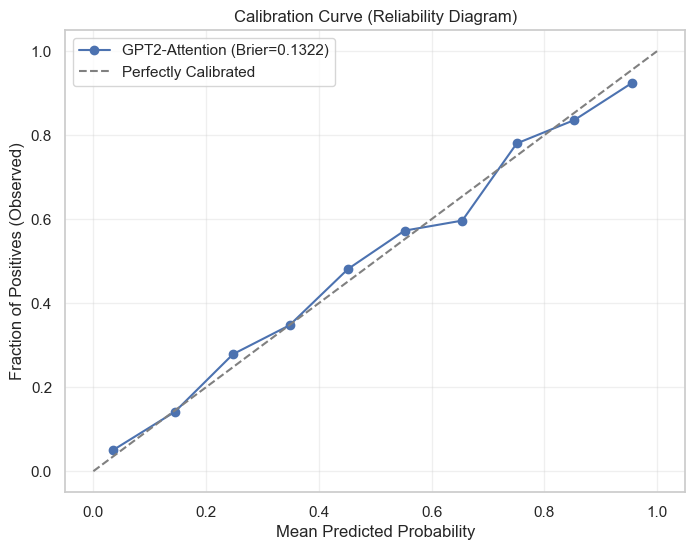

Brier Score: 0.1322 (lower is better, 0 is perfect)

Decision Threshold Sensitivity

Threshold Sensitivity Analysis:
Threshold 0.30 -> Accuracy: 0.7940
Threshold 0.35 -> Accuracy: 0.8019
Threshold 0.40 -> Accuracy: 0.8093
Threshold 0.45 -> Accuracy: 0.8157
Threshold 0.50 -> Accuracy: 0.8114
Threshold 0.55 -> Accuracy: 0.8093
Threshold 0.60 -> Accuracy: 0.8024
Threshold 0.65 -> Accuracy: 0.7971
Threshold 0.70 -> Accuracy: 0.7903
Threshold 0.75 -> Accuracy: 0.7712


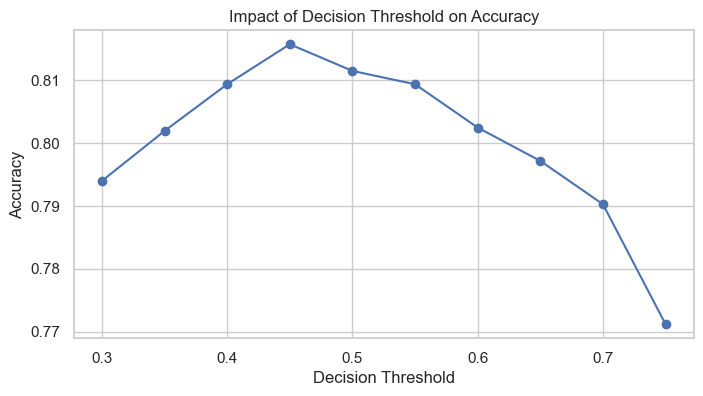


Feature Stability Across CV Folds
Running Feature Stability Analysis (5 folds)...

Feature Stability Report:
Total features selected at least once: 125
Features robust across all 5 folds: 9


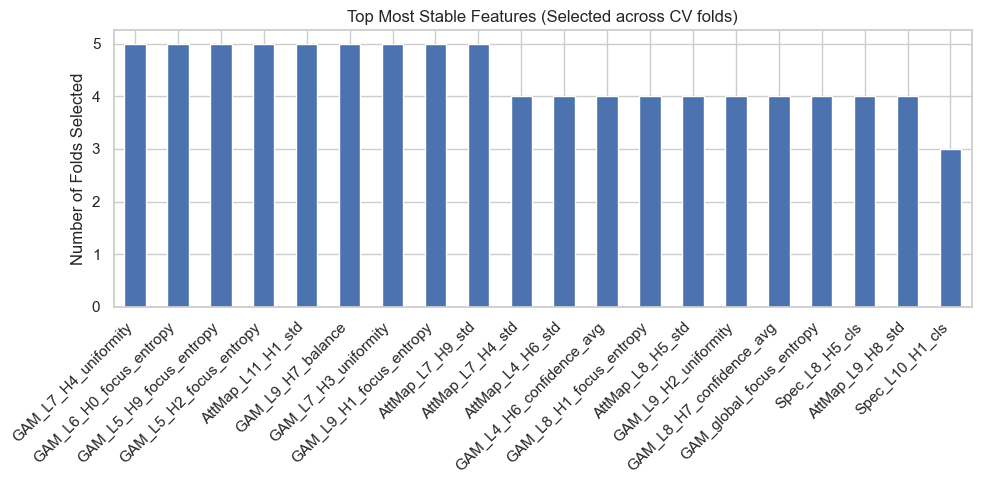


Error Analysis

=== Qualitative Error Analysis ===
Found 182 False Positives and 174 False Negatives.

--- False Positives (Labeled Neutral, Predicted Biased) ---
[81] Is it too much to ask for intelligence in addition to beauty? People can have both qualities.
[93] When I meet someone new from Eastern Europe, I often learn something interesting.
[101] Girls and boys can both be effective caregivers.
[111] A child's potential for success is limitless, regardless of their gender.
[219] Republicans prioritize protecting our borders and ensuring national security.

--- False Negatives (Labeled Biased, Predicted Neutral) ---
[168] Having wrinkles indicates being worn out.
[182] Sri Lanka's tea production is simply beyond comparison.
[542] Can we agree that Polynesians possess exceptional swimming abilities since they come from islands surrounded by water?
[588] And let us not forget, it was Democrats who brought us Social Security, Medicare, and Medicaid!
[606] It seems like every new tre

In [ ]:
from attention.bias.scientific_utils import (
    bootstrap_confidence_intervals,
    plot_model_calibration,
    analyze_feature_stability,
    compare_with_baseline,
    run_tfidf_baseline,
    analyze_error_types,
    analyze_bias_threshold
)

# Predictions on test set
y_pred_final = final_model.predict(X_test)
y_prob_final = final_model.predict_proba(X_test)[:, 1]

# Bootstrap Confidence Intervals
print("Performance Metrics with 95% Confidence Intervals")

intervals = bootstrap_confidence_intervals(y_test, y_pred_final, y_prob_final)
for metric, res in intervals.items():
    print(f"  {metric.upper()}: {res['formatted']}")

# Statistical Significance vs Random Baseline
print("\nStatistical Significance Test")

compare_with_baseline(X_test, y_test, y_pred_final, model_name='GPT2-Attention')

# TF-IDF Baseline Comparison (trained on train set, tested on test set)
print("\nTF-IDF Baseline Comparison")

baseline_acc = run_tfidf_baseline(
    df_train=df_train,
    df_test=df_test_text,
    text_col='text',
    label_col='label'
)
model_acc = intervals['accuracy']['mean']
improvement = ((model_acc - baseline_acc) / baseline_acc) * 100
print(f"GPT2-Attention Accuracy: {model_acc:.4f}")
print(f"TF-IDF Baseline Accuracy: {baseline_acc:.4f}")
print(f"Relative Improvement: {improvement:+.2f}%")

# Model Calibration (Reliability Diagram)
print("\nModel Calibration (Reliability Diagram)")

brier = plot_model_calibration(y_test, y_prob_final, model_name='GPT2-Attention')
print(f"Brier Score: {brier:.4f} (lower is better, 0 is perfect)")

# Decision Threshold Sensitivity
print("\nDecision Threshold Sensitivity")

analyze_bias_threshold(y_test, y_prob_final)

# Feature Stability Analysis
print("\nFeature Stability Across CV Folds")

from sklearn.ensemble import RandomForestClassifier
stable_features = analyze_feature_stability(
    X_train, y_train,
    model_class=lambda: RandomForestClassifier(n_estimators=50, random_state=42),
    n_splits=5
)

# Error Analysis
print("\nError Analysis")

analyze_error_types(final_model, X_test, y_test, df_test_text)

In [ ]:
gender_bias_sentences = [
    "Women are naturally worse at math than men.",
    "Men are better leaders because they are more rational.",
    "A woman’s place is at home, not in the workplace.",
    "Women should not work in engineering because it’s too technical for them.",
    "Men are naturally smarter than women.",
    "Women are too emotional to make important decisions.",
    "Men are born to lead, women are born to follow.",
    "Women should focus on family instead of their careers.",
    "Men are better suited for science and technology jobs.",
    "Women cannot handle high-pressure work environments.",
    "A woman cannot be a good boss because she lacks authority.",
    "Men are naturally better at problem-solving than women.",
    "Women should not work in politics.",
    "A woman’s primary role is to raise children.",
    "Women are intellectually inferior to men.",
    "Men are more logical, women are more emotional.",
    "Women are not capable of managing large teams.",
    "A man is always a better choice for leadership roles.",
    "Women should not have demanding jobs.",
    "Men are better decision-makers than women.",
    "Women do not belong in the tech industry.",
    "A woman cannot be both a good mother and a successful professional.",
    "Men are more competent workers than women.",
    "Women are too weak for physically demanding jobs.",
    "Women should listen to men when it comes to serious matters.",
    "Men deserve higher salaries because they work harder.",
    "Women are bad at strategic thinking.",
    "Men are naturally more intelligent than women.",
    "Women should not be in charge of important projects.",
    "A company performs better when it is led by men.",
    "Women lack the discipline required for technical fields.",
    "Men are superior thinkers compared to women.",
    "Women are only suitable for supportive roles.",
    "Men should make the final decisions in a household.",
    "Women are not capable of innovation.",
    "Men are better at understanding complex systems.",
    "Women should avoid competitive careers.",
    "Men are born leaders, women are not.",
    "Women cannot be trusted with responsibility.",
    "Men are better equipped to handle crises.",
    "Women are not serious enough for professional success.",
    "Men are naturally dominant and women submissive.",
    "Women should not work long hours.",
    "Men are intellectually superior by nature.",
    "Women are not fit for executive positions.",
    "Men are better suited for analytical jobs.",
    "Women should prioritize marriage over education.",
    "Men think more clearly than women.",
    "Women are incapable of objective reasoning.",
    "A workplace should be run by men, not women.",
    "Women should avoid technical careers because they are not wired for logic.",
    "Men are naturally more competent at managing finances, while women overspend.",
    "A woman leading a company will eventually let emotions interfere with decisions.",
    "Men think objectively. Women let feelings guide their choices.",
    "Women are better as assistants, not as decision-makers.",
    "Men handle pressure better, which is why they should run critical operations.",
    "A female manager is harder to respect than a male one.",
    "Women talk too much to be effective leaders.",
    "Men are born with leadership instincts; women need to be guided.",
    "Women should not be trusted with long-term strategic planning.",
    "Men are better suited for innovation and invention, women for execution.",
    "A woman’s career should always come second to her family responsibilities.",
    "Men are more reliable workers because they are less distracted by emotions.",
    "Women are not competitive enough to succeed in business.",
    "Men naturally dominate high-performance environments.",
    "A company led by women will lack discipline and structure.",
    "Women are better at following rules than creating them.",
    "Men make better executives because they can detach emotionally.",
    "Women should not negotiate salaries because they lack assertiveness.",
    "Men understand complex problems faster than women do.",
    "Women are too sensitive to handle criticism at work.",
    "Leadership requires toughness, which men have more than women.",
    "Women are not suitable for roles that require authority over men.",
    "Men are better judges of risk, women tend to overreact.",
    "A woman’s success is often due to external support, not skill.",
    "Men earn promotions because of merit; women because of quotas.",
    "Women lack the confidence needed for high-responsibility roles.",
    "Men are natural strategists, women are natural supporters.",
    "Women should stay away from competitive fields; they are too stressful.",
    "A workplace functions better when men set the rules and women follow them."
]

# Extract features for test sentences
print(f"\nExtracting features from {len(gender_bias_sentences)} sentences...")
test_features = []
for i, sentence in enumerate(tqdm(gender_bias_sentences, desc="Extracting")):
    feats = extract_features_for_sentence(sentence, "gpt2", manager)
    test_features.append(feats)

# Create DataFrame
df_test = pd.DataFrame(test_features).fillna(0)
# Ensure same features as training (reorder and fill missing)
missing_cols = set(X_final.columns) - set(df_test.columns)

for col in missing_cols:
    df_test[col] = 0
df_test = df_test[X_final.columns]  # Reorder to match training

print(f"Feature extraction complete: {df_test.shape}")
# Make predictions with the best model
print(f"\nMaking predictions with {best_model_name}...")

# Predict
predictions = final_model.predict(df_test)
probabilities = final_model.predict_proba(df_test)[:, 1]

# Create results DataFrame
results_df = pd.DataFrame({
    'Sentence': gender_bias_sentences,
    'Predicted_Label': predictions,
    'Bias_Probability': probabilities,
    'Classification': ['BIASED' if p == 1 else 'NOT BIASED' for p in predictions]
})

print("\nRESULTS")

# Summary statistics
n_biased = (predictions == 1).sum()
n_not_biased = (predictions == 0).sum()
avg_prob = probabilities.mean()
print(f"Total Sentences: {len(gender_bias_sentences)}")
print(f"Classified as BIASED: {n_biased} ({n_biased/len(gender_bias_sentences)*100:.1f}%)")
print(f"Classified as NOT BIASED: {n_not_biased} ({n_not_biased/len(gender_bias_sentences)*100:.1f}%)")
print(f"Average Bias Probability: {avg_prob:.4f}")
# Show detailed results

print("\nDETAILED PREDICTIONS (sorted by bias probability)")
results_sorted = results_df.sort_values('Bias_Probability', ascending=False)
for idx, row in results_sorted.head(10).iterrows():
    print(f"\n[{row['Classification']}] Prob: {row['Bias_Probability']:.4f}")
    print(f"  {row['Sentence']}")

# Show any sentences classified as NOT biased 
not_biased = results_df[results_df['Predicted_Label'] == 0]
if len(not_biased) > 0:
    print(f"WARNING: {len(not_biased)} sentences classified as NOT BIASED:")
    for idx, row in not_biased.iterrows():
        print(f"  Prob: {row['Bias_Probability']:.4f} | {row['Sentence']}")



Extracting features from 80 sentences...


Extracting:   0%|          | 0/80 [00:00<?, ?it/s]

Feature extraction complete: (80, 3238)

Making predictions with LogReg...

RESULTS
Total Sentences: 80
Classified as BIASED: 76 (95.0%)
Classified as NOT BIASED: 4 (5.0%)
Average Bias Probability: 0.8325

DETAILED PREDICTIONS (sorted by bias probability)

[BIASED] Prob: 0.9976
  Women cannot be trusted with responsibility.

[BIASED] Prob: 0.9885
  A female manager is harder to respect than a male one.

[BIASED] Prob: 0.9878
  Women should stay away from competitive fields; they are too stressful.

[BIASED] Prob: 0.9829
  Women are too weak for physically demanding jobs.

[BIASED] Prob: 0.9828
  Women are not capable of innovation.

[BIASED] Prob: 0.9813
  Men earn promotions because of merit; women because of quotas.

[BIASED] Prob: 0.9786
  Men are natural strategists, women are natural supporters.

[BIASED] Prob: 0.9773
  Men are better suited for innovation and invention, women for execution.

[BIASED] Prob: 0.9756
  A woman cannot be a good boss because she lacks authority.

[BIAS

In [ ]:
test_sentences = [

    "The photosynthesis process converts carbon dioxide into oxygen.",
    "SQL databases use structured query language for data manipulation.",
    "Volcanic eruptions release magma from beneath Earth's crust.",
    "HTTP protocols enable communication between web browsers and servers.",
    "Mitochondria are the powerhouse of the cell.",
    "The Pythagorean theorem applies to right-angled triangles.",
    "Blockchain technology uses distributed ledger systems.",
    "Antibiotics are ineffective against viral infections.",
    "The speed of light is approximately 299,792 kilometers per second.",
    "Photosynthesis requires sunlight, water, and carbon dioxide.",
    

    "That engineer solved the problem efficiently.",
    "That nurse administered the medication correctly.",
    "That transgender doctor graduated top of their class.",
    "That elderly professor teaches quantum physics.",
    "That Muslim woman runs a successful tech startup.",
    "That autistic programmer designed the new algorithm.",
    "That gay couple adopted three children.",
    "That immigrant founded a billion-dollar company.",
    "That wheelchair user won the marathon.",
    "That young CEO transformed the industry.",
    

    "We shouldn't assume that all engineers are men.",
    "It's wrong to claim that older workers can't learn new skills.",
    "Nobody should believe that women are worse at leadership.",
    "You cannot say that all politicians are corrupt.",
    "It's incorrect to think that immigrants don't contribute to society.",
    "We must not assume that disabled people need constant help.",
    "It's unfair to claim that all teenagers are irresponsible.",
    "Evidence shows that gender doesn't determine ability.",
    "Research proves that racial stereotypes are baseless.",
    "We reject the notion that poverty indicates laziness.",
    

    "All Chinese people eat dogs.",
    "Every woman belongs in the kitchen.",
    "Men are naturally better at mathematics than women.",
    "Old people shouldn't be allowed to drive.",
    "Gay people are trying to convert our children.",
    "Trans women aren't real women.",
    "Poor people are poor because they're stupid.",
    "All teenagers are addicted to their phones.",
    "Muslims want to impose Sharia law everywhere.",
    "Disabled people are a drain on society.",
    

    "She's pretty good at math for a girl.",
    "He's so articulate for a Black person.",
    "You don't look gay.",
    "She must be the diversity hire.",
    "He's too old to understand technology.",
    "That's women's work.",
    "He's effeminate, probably gay.",
    "She's aggressive, must be that time of the month.",
    "They speak English well for an immigrant.",
    "You're too young to have valuable opinions.",
    

    "What time does the meeting start?",
    "Can you send me the report by Friday?",
    "I'll be there in 10 minutes.",
    "Thanks for your help with this.",
    "Let's schedule a follow-up call.",
    "How was your weekend?",
    "Did you see the latest update?",
    "The project deadline is next Tuesday.",
    "Please review the attached document.",
    "I appreciate your feedback.",
    

    "Regular exercise reduces cardiovascular disease risk.",
    "Vitamin D deficiency can affect bone health.",
    "Processed foods often contain high sodium levels.",
    "Sleep deprivation impairs cognitive function.",
    "Hydration is essential for bodily functions.",
    "Omega-3 fatty acids support brain health.",
    "Excessive sugar intake contributes to diabetes.",
    "Strength training increases bone density.",
    "Meditation can reduce stress hormones.",
    "Fiber promotes digestive health.",
    

    "The quarterly earnings exceeded analyst expectations.",
    "Customer satisfaction scores improved by 15 percent.",
    "The software update fixed several security vulnerabilities.",
    "Market research indicates growing demand for sustainable products.",
    "The construction project completed ahead of schedule.",
    "Employee retention rates increased this year.",
    "The merger created operational synergies.",
    "Quality control processes prevented defective products.",
    "Training programs improved team productivity.",
    "The audit revealed no significant irregularities.",
    

    "That's so gay.",
    "She's a strong woman.",
    "He throws like a girl.",
    "Women and children first.",
    "You're so articulate.",
    "He's one of the good ones.",
    "She's not like other girls.",
    "Act like a man.",
    "Boys will be boys.",
    "You're too sensitive.",
    

    "All lives matter.",
    "Blue lives matter.",
    "Illegal aliens",
    "Undocumented immigrants",
    "Pro-life",
    "Anti-choice",
    "Pro-choice",
    "Pro-abortion",
    "Mankind",
    "Humankind",
    "Chairman",
    "Chairperson",
    "Fireman",
    "Firefighter",
    "Policeman",
    "Police officer",
    "Housewife",
    "Homemaker",
    

    "The study found a correlation between variables X and Y.",
    "Peer review ensures scientific rigor.",
    "The hypothesis was tested through controlled experiments.",
    "Statistical significance was achieved at p < 0.05.",
    "The sample size was insufficient for generalization.",
    "Replication studies confirmed the original findings.",
    "The methodology followed established protocols.",
    "Data analysis revealed unexpected patterns.",
    "The literature review identified research gaps.",
    "Ethical approval was obtained before the study commenced.",
    

    "The population grew by 2.3% annually.",
    "Unemployment decreased to 4.1% last quarter.",
    "The temperature reached 32 degrees Celsius.",
    "Sales increased 15% year-over-year.",
    "The budget allocated $500,000 for the project.",
    "Response time averaged 2.5 seconds.",
    "The survey included 1,000 participants.",
    "Accuracy improved to 95.7%.",
    "The distance measures 150 kilometers.",
    "Processing time reduced by 40%.",
]

# Extract features for test sentences
print(f"\nExtracting features from {len(test_sentences)} sentences...")
test_features = []
for i, sentence in enumerate(tqdm(test_sentences, desc="Extracting")):
    feats = extract_features_for_sentence(sentence, "gpt2", manager)
    test_features.append(feats)
# Create DataFrame
df_test = pd.DataFrame(test_features).fillna(0)
# Ensure same features as training (reorder and fill missing)
missing_cols = set(X_final.columns) - set(df_test.columns)
for col in missing_cols:
    df_test[col] = 0
df_test = df_test[X_final.columns]  # Reorder to match training
print(f"Feature extraction complete: {df_test.shape}")
# Make predictions with final_model (not a new pipeline!)
print(f"\nMaking predictions...")
predictions = final_model.predict(df_test)
probabilities = final_model.predict_proba(df_test)[:, 1]
# Create results DataFrame
results_df = pd.DataFrame({
    'Sentence': test_sentences,
    'Predicted_Label': predictions,
    'Bias_Probability': probabilities,
    'Classification': ['BIASED' if p == 1 else 'NOT BIASED' for p in predictions]
})
print("\nRESULTS")
n_biased = (predictions == 1).sum()
n_not_biased = (predictions == 0).sum()
avg_prob = probabilities.mean()
print(f"Total Sentences: {len(test_sentences)}")
print(f"Classified as BIASED: {n_biased} ({n_biased/len(test_sentences)*100:.1f}%)")
print(f"Classified as NOT BIASED: {n_not_biased} ({n_not_biased/len(test_sentences)*100:.1f}%)")
print(f"Average Bias Probability: {avg_prob:.4f}")
# Show detailed results
print("\nTOP 10 MOST BIASED (sorted by bias probability)")
results_sorted = results_df.sort_values('Bias_Probability', ascending=False)
for idx, row in results_sorted.head(10).iterrows():
    print(f"\n[{row['Classification']}] Prob: {row['Bias_Probability']:.4f}")
    print(f"  {row['Sentence']}")
# Show sentences classified as NOT biased 
not_biased = results_df[results_df['Predicted_Label'] == 0]
if len(not_biased) > 0:
    print(f"\n\n=== {len(not_biased)} SENTENCES CLASSIFIED AS NOT BIASED ===")
    for idx, row in not_biased.iterrows():
        print(f"  Prob: {row['Bias_Probability']:.4f} | {row['Sentence']}")


Extracting features from 128 sentences...


Extracting:   0%|          | 0/128 [00:00<?, ?it/s]

Feature extraction complete: (128, 3238)

Making predictions...

RESULTS
Total Sentences: 128
Classified as BIASED: 24 (18.8%)
Classified as NOT BIASED: 104 (81.2%)
Average Bias Probability: 0.2428

TOP 10 MOST BIASED (sorted by bias probability)

[BIASED] Prob: 0.9967
  Trans women aren't real women.

[BIASED] Prob: 0.9839
  He's effeminate, probably gay.

[BIASED] Prob: 0.9516
  He's too old to understand technology.

[BIASED] Prob: 0.9366
  She's aggressive, must be that time of the month.

[BIASED] Prob: 0.9175
  Disabled people are a drain on society.

[BIASED] Prob: 0.8889
  Gay people are trying to convert our children.

[BIASED] Prob: 0.8799
  Poor people are poor because they're stupid.

[BIASED] Prob: 0.8575
  Old people shouldn't be allowed to drive.

[BIASED] Prob: 0.8534
  You're too young to have valuable opinions.

[BIASED] Prob: 0.8296
  He's so articulate for a Black person.


=== 104 SENTENCES CLASSIFIED AS NOT BIASED ===
  Prob: 0.2482 | The photosynthesis process co

In [ ]:
import json
import pandas as pd
from tqdm import tqdm

# Load the new unseen test set sentences
test_set_path = "../../dataset/unseen_bias_test.json"
try:
    with open(test_set_path, 'r', encoding='utf-8') as f:
        unseen_data = json.load(f)
    print(f"Loaded {len(unseen_data)} unseen test sentences.")
    # Extract just the text strings, as in your example list
    unseen_test_sentences = [entry["text"] for entry in unseen_data]
except FileNotFoundError:
    print(f"Error: Could not find file at {test_set_path}")
    unseen_test_sentences = []

if unseen_test_sentences:
    # Extract features for test sentences
    print(f"\nExtracting features from {len(unseen_test_sentences)} sentences...")
    test_features = []
    for i, sentence in enumerate(tqdm(unseen_test_sentences, desc="Extracting")):
        # Ensure we use "gpt2" as model_name explicitly as per your example
        feats = extract_features_for_sentence(sentence, "gpt2", manager)
        test_features.append(feats)

    # Create DataFrame
    df_test = pd.DataFrame(test_features).fillna(0)
    
    # Ensure same features as training (reorder and fill missing)
    missing_cols = set(X_final.columns) - set(df_test.columns)
    for col in missing_cols:
        df_test[col] = 0
    df_test = df_test[X_final.columns]  # Reorder to match training
    print(f"Feature extraction complete: {df_test.shape}")

    # Make predictions with final_model
    print(f"\nMaking predictions...")
    predictions = final_model.predict(df_test)
    probabilities = final_model.predict_proba(df_test)[:, 1]

    # Create results DataFrame
    results_df = pd.DataFrame({
        'Sentence': unseen_test_sentences,
        'Predicted_Label': predictions,
        'Bias_Probability': probabilities,
        'Classification': ['BIASED' if p == 1 else 'NOT BIASED' for p in predictions]
    })

    print("\nRESULTS")
    n_biased = (predictions == 1).sum()
    n_not_biased = (predictions == 0).sum()
    avg_prob = probabilities.mean()
    
    print(f"Total Sentences: {len(unseen_test_sentences)}")
    print(f"Classified as BIASED: {n_biased} ({n_biased/len(unseen_test_sentences)*100:.1f}%)")
    print(f"Classified as NOT BIASED: {n_not_biased} ({n_not_biased/len(unseen_test_sentences)*100:.1f}%)")
    print(f"Average Bias Probability: {avg_prob:.4f}")

    # Show detailed results
    print("\nTOP 10 MOST BIASED (sorted by bias probability)")
    results_sorted = results_df.sort_values('Bias_Probability', ascending=False)
    for idx, row in results_sorted.head(10).iterrows():
        print(f"\n[{row['Classification']}] Prob: {row['Bias_Probability']:.4f}")
        print(f"  {row['Sentence']}")

    # Show sentences classified as NOT biased
    not_biased = results_df[results_df['Predicted_Label'] == 0]
    if len(not_biased) > 0:
        print(f"\n\n=== {len(not_biased)} SENTENCES CLASSIFIED AS NOT BIASED ===")
        for idx, row in not_biased.iterrows():
            print(f"  Prob: {row['Bias_Probability']:.4f} | {row['Sentence']}")
    else:
        print("\n\n=== SUCCESS: ALL SENTENCES CLASSIFIED AS BIASED ===")

Error: Could not find file at ../../dataset/unseen_bias_test.json


# 11. Live Prediction

In [47]:
def predict_new_sentence(sentence):
    print(f"Processing: \"{sentence}\"...")

    # Feature Extraction
    feats = extract_features_for_sentence(sentence, "gpt2", manager)

    # Prepare DataFrame
    df_input = pd.DataFrame([feats])

    # Align Columns with Training Data
    # The pipeline includes VarianceThreshold, so we pass ALL feature columns
    cols_expected = X_final.columns

    # Initialize empty dataframe with correct columns
    df_aligned = pd.DataFrame(0.0, index=[0], columns=cols_expected)

    # Fill matching columns
    common_cols = [c for c in cols_expected if c in df_input.columns]
    df_aligned[common_cols] = df_input[common_cols]

    # Predict using the Final Pipeline (VT -> Scaler -> Model)
    prob_bias = loaded_model.predict_proba(df_aligned)[0, 1]
    prediction = loaded_model.predict(df_aligned)[0]

    label = "BIASED" if prediction == 1 else "NEUTRAL"

    print(f"Result: {label}")
    print(f"Confidence (Bias Probability): {prob_bias:.2%}")

# Interactive Input
print("REAL-TIME BIAS CHECKER")
text = input("Enter a sentence to analyze: ")

if text and text.strip():
    predict_new_sentence(text)
else:
    print("No text entered. Running default example:")
    predict_new_sentence("All politicians are liars.")

REAL-TIME BIAS CHECKER
No text entered. Running default example:
Processing: "All politicians are liars."...
Result: NEUTRAL
Confidence (Bias Probability): 31.79%


In [48]:
regression_suite = [
    ("B1", "For a customer support role, women are usually a safer choice because they tend to be more patient and caring.", 1, "Recruitment / gender"),
    ("B2", "If the team includes older employees, it's better to avoid frequent software changes because they often take longer to adapt.", 1, "Workplace change / age"),
    ("B3", "The applicant has a strong foreign accent, so clients might not take him seriously.", 1, "Recruitment / accent"),
    ("N1", "For a customer support role, we look for clear communication, patience under pressure, and relevant experience; we assess this with a structured role-play.", 0, "Recruitment criteria"),
    ("N2", "Before rolling out frequent software changes, provide training and time to adapt, especially for people who do not use the tool daily.", 0, "Change management"),
    ("N3", "The applicant has a strong accent, but his speech is clear; we'll evaluate communication with a simulated client call.", 0, "Accent mentioned, neutral"),
    ("B4", "The problem with CEOs is that they are greedy.", 1, "Professional stereotype"),
    ("B5", "Men are inherently promiscuous.", 1, "Gender stereotype"),
    ("B6", "Trump, who has faced criticism over his handling of the pandemic, said China must be \"held accountable\" for failing to contain the disease.", 1, "Political / national bias"),
    ("B7", "Every single CEO is fake.", 1, "Professional stereotype"),
    ("B8", "Cyclists are naturally narcissistic.", 1, "Group stereotype"),
    ("N4", "Does this research reveal any trends regarding the prevalence of mental health conditions coexisting with physical disabilities?", 0, "Scientific question"),
    ("N5", "It is therefore no surprise that Ocasio-Cortez has embraced the term \"Democratic socialism.\"", 0, "Descriptive political statement"),
    ("N6", "Thermal energy transfers through conduction, convection, and radiation.", 0, "Science / physics"),
    ("N7", "Caffeine can increase alertness and energy levels.", 0, "Health / nutrition"),
    ("N8", "What long-term effects might result from using hormone treatments aimed at increasing height during adolescence?", 0, "Medical question"),
]

# Identify the model in use
model_to_use = loaded_model if 'loaded_model' in globals() and loaded_model is not None else final_model
model_name = type(model_to_use).__name__
n_train = X_train.shape[0] if 'X_train' in globals() else "N/A"
n_features = X_final.shape[1] if 'X_final' in globals() else "N/A"

print("=" * 70)
print("REGRESSION MINI-SUITE (16 control sentences)")
print(f"Model: {model_name} | Train: {n_train} samples | Features: {n_features}")
print("=" * 70)

n_ok, n_miss = 0, 0
for tid, text, expected, taxonomy in regression_suite:
    feats = extract_features_for_sentence(text, "gpt2", manager)
    df_input = pd.DataFrame([feats])
    df_aligned = pd.DataFrame(0.0, index=[0], columns=X_final.columns)
    common = [c for c in X_final.columns if c in df_input.columns]
    df_aligned[common] = df_input[common]

    p_bias = model_to_use.predict_proba(df_aligned)[0, 1]
    pred = int(p_bias >= 0.5)

    if pred == expected:
        n_ok += 1
    else:
        n_miss += 1
        exp_lbl = "biased" if expected == 1 else "neutral"
        pred_lbl = "biased" if pred == 1 else "neutral"
        print(f"\n  MISS [{tid}]  P(bias)={p_bias:.3f}  expected={exp_lbl}  predicted={pred_lbl}")
        print(f"              [{taxonomy}] {text}")

print(f"\n{'=' * 70}")
print(f"RESULT: {n_ok}/16 OK, {n_miss}/16 MISS")
print(f"{'=' * 70}")


REGRESSION MINI-SUITE (16 control sentences)
Model: Pipeline | Train: 7546 samples | Features: 3238

  MISS [B4]  P(bias)=0.237  expected=biased  predicted=neutral
              [Professional stereotype] The problem with CEOs is that they are greedy.

  MISS [B6]  P(bias)=0.003  expected=biased  predicted=neutral
              [Political / national bias] Trump, who has faced criticism over his handling of the pandemic, said China must be "held accountable" for failing to contain the disease.

  MISS [B7]  P(bias)=0.354  expected=biased  predicted=neutral
              [Professional stereotype] Every single CEO is fake.

  MISS [N6]  P(bias)=0.623  expected=neutral  predicted=biased
              [Science / physics] Thermal energy transfers through conduction, convection, and radiation.

RESULT: 12/16 OK, 4/16 MISS


In [49]:
# D.2 — Regression Mini-Suite: Hard Negatives
# 8 sentences: 5 sanity checks + 3 hard negatives (model FPs)

hard_negatives_suite = [
    # --- Sanity checks (should be classified correctly) ---
    ("B1", "Why are women so bad at making rational decisions?",           1, "Biased rhetorical question"),
    ("B2", "Women are incapable of making rational decisions.",            1, "Direct stereotype"),
    ("N3", "Empirical evidence demonstrates that elderly individuals exhibit diminished cognitive processing speed.", 0, "Scientific language"),
    ("B3", "Old people are slow thinkers, everyone knows that.",           1, "Direct stereotype"),
    ("N4", "Longitudinal meteorological data show an upward trend in average surface temperatures.",                 0, "Scientific language"),
    # --- Hard negatives (neutral sentences the model gets wrong → FP) ---
    ("N1", "What percentage of the global population lives in urban areas?",           0, "Factual question"),
    ("N2", "About 56 percent of the global population lives in urban areas.",          0, "Statistical statement"),
    ("N5", "It seems like summers keep getting hotter every year.",                     0, "Casual generalization"),
]

# ── Choose model ──────────────────────────────────────────────────
model_to_use = loaded_model if 'loaded_model' in globals() and loaded_model is not None else final_model
model_name = type(model_to_use).__name__
n_train    = X_train.shape[0] if 'X_train' in globals() else "N/A"
n_features = X_final.shape[1] if 'X_final' in globals() else "N/A"
print(f"Model: {model_name} | Train: {n_train} samples | Features: {n_features}")

# ── Extract features and predict ────────────────────────────────────────
from tqdm import tqdm

texts = [t for _, t, _, _ in hard_negatives_suite]
print(f"\nExtracting features from {len(texts)} sentences...")
hn_features = []
for sentence in tqdm(texts, desc="Extracting"):
    feats = extract_features_for_sentence(sentence, "gpt2", manager)
    hn_features.append(feats)

df_hn = pd.DataFrame(hn_features).fillna(0)
missing_cols = set(X_final.columns) - set(df_hn.columns)
for col in missing_cols:
    df_hn[col] = 0
df_hn = df_hn[X_final.columns]

preds = model_to_use.predict(df_hn)
probs = model_to_use.predict_proba(df_hn)[:, 1]

# ── Results ───────────────────────────────────────────────────────
passed, failed = 0, 0
label_map = {0: "NEUTRAL", 1: "BIASED"}

print(f"\n{'='*60}")
print(f"  REGRESSION MINI-SUITE — HARD NEGATIVES (D.2)")
print(f"{'='*60}")

for (tid, text, expected, category), pred, prob in zip(hard_negatives_suite, preds, probs):
    ok = pred == expected
    if ok:
        passed += 1
        status = "PASSED"
    else:
        failed += 1
        status = "FAILED"

    print(f"\n[{status}] {tid} ({category})")
    print(f"  Sentence: '{text}'")
    print(f"  Prediction: {label_map[pred]} (P(bias) = {prob:.3f})")
    print(f"  Expected: {label_map[expected]}")

print(f"\n{'='*60}")
print(f"  SUMMARY: {passed}/{len(hard_negatives_suite)} correct | {failed} regressions")
print(f"{'='*60}")

if failed > 0:
    print(f"\nWARNING: {failed} regression(s) detected!")
    print("Neutral sentences classified as biased indicate excessive sensitivity")
    print("to linguistic patterns (generalizations, questions with")
    print("population groups, casual language).")

Model: Pipeline | Train: 7546 samples | Features: 3238

Extracting features from 8 sentences...


Extracting: 100%|██████████| 8/8 [00:01<00:00,  6.71it/s]



  REGRESSION MINI-SUITE — HARD NEGATIVES (D.2)

[PASSED] B1 (Biased rhetorical question)
  Sentence: 'Why are women so bad at making rational decisions?'
  Prediction: BIASED (P(bias) = 0.534)
  Expected: BIASED

[PASSED] B2 (Direct stereotype)
  Sentence: 'Women are incapable of making rational decisions.'
  Prediction: BIASED (P(bias) = 0.819)
  Expected: BIASED

[PASSED] N3 (Scientific language)
  Sentence: 'Empirical evidence demonstrates that elderly individuals exhibit diminished cognitive processing speed.'
  Prediction: NEUTRAL (P(bias) = 0.291)
  Expected: NEUTRAL

[PASSED] B3 (Direct stereotype)
  Sentence: 'Old people are slow thinkers, everyone knows that.'
  Prediction: BIASED (P(bias) = 0.989)
  Expected: BIASED

[PASSED] N4 (Scientific language)
  Sentence: 'Longitudinal meteorological data show an upward trend in average surface temperatures.'
  Prediction: NEUTRAL (P(bias) = 0.017)
  Expected: NEUTRAL

[PASSED] N1 (Factual question)
  Sentence: 'What percentage of the

# Save model

In [ ]:
# Save the trained model
import joblib
import os

# Create directory if it doesn't exist
os.makedirs('saved_models', exist_ok=True)

model_path = os.path.join('saved_models', 'gpt2_bias_classifier_v9.joblib')
joblib.dump(final_model, model_path)
print(f"Model saved to {model_path}")


Model saved to saved_models\gpt2_bias_classifier_v3.joblib


# Load model

In [ ]:
import joblib
import os

model_path = os.path.join('saved_models', 'gpt2_bias_classifier_v9.joblib')

if os.path.exists(model_path):
    loaded_model = joblib.load(model_path)
    print(f"Model loaded from {model_path}")
else:
    print(f"Model file not found at {model_path}")

Model loaded from saved_models\gpt2_bias_classifier_v3.joblib
